# Unified Stress and Anxiety Classification Experiments


In [1]:
# Unified Stress and Anxiety Classification Experiments
# All models use the same train/test split and cross-validation methodology

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Classification model imports
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler

# Classification metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

# SMOTE for handling class imbalance
try:
    from imblearn.over_sampling import SMOTE
    SMOTE_AVAILABLE = True
except ImportError:
    print("Warning: imbalanced-learn not installed. Install with: pip install imbalanced-learn")
    SMOTE_AVAILABLE = False

# Configuration
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 140)
sns.set_style("whitegrid")

DATA_PATH = Path("masterfiles/all_users_all_metrics.csv")
SEED = 42
np.random.seed(SEED)

# Target columns
TARGET_STRESS = "dq_stress level"
TARGET_ANX = "dq_anxiety level"

print("Libraries imported successfully")


Libraries imported successfully


## 1. Data Loading and Basic Cleaning


In [2]:
# Load data
df = pd.read_csv(DATA_PATH)

# Normalize core types
df["date"] = pd.to_datetime(df["date"], errors="coerce")
df["user_id"] = df["user_id"].astype(str)

# Drop rows without date or user_id
df = df.dropna(subset=["date", "user_id"]).copy()

# Sort by user and date
df = df.sort_values(["user_id", "date"]).reset_index(drop=True)

print("Shape:", df.shape)
print("Date range:", df["date"].min(), "→", df["date"].max())
df.head()


Shape: (3467, 14)
Date range: 2025-01-30 00:00:00 → 2025-07-01 00:00:00


,user_id,date,overall_score_previous_day,deep_sleep_in_minutes_previous_day,overall_score,deep_sleep_in_minutes,oxygen_saturation_average_value,oxygen_saturation_average_value_previous_day,rmssd,rmssd_previous_day,daily_respiratory_rate,daily_respiratory_rate_previous_day,dq_stress level,dq_anxiety level
0,1,2025-02-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15.0,0.0
1,1,2025-02-05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,33.0,0.0
2,1,2025-02-06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12.0,0.0
3,1,2025-02-07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.0,8.0
4,1,2025-02-08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.0,7.0


## 2. Aggregate to Daily Level


In [3]:
# Aggregate to daily level (mean of numeric columns per user per day)
df["day"] = df["date"].dt.floor("D")
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()

daily = (df.groupby(["user_id", "day"], as_index=False)[num_cols]
           .mean()
           .sort_values(["user_id", "day"]))

daily = daily.rename(columns={"day": "date"})
print("Daily shape:", daily.shape)
daily.head()


Daily shape: (3467, 14)


,user_id,date,overall_score_previous_day,deep_sleep_in_minutes_previous_day,overall_score,deep_sleep_in_minutes,oxygen_saturation_average_value,oxygen_saturation_average_value_previous_day,rmssd,rmssd_previous_day,daily_respiratory_rate,daily_respiratory_rate_previous_day,dq_stress level,dq_anxiety level
0,1,2025-02-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15.0,0.0
1,1,2025-02-05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,33.0,0.0
2,1,2025-02-06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12.0,0.0
3,1,2025-02-07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.0,8.0
4,1,2025-02-08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.0,7.0


## 3. Feature Engineering


In [4]:
# Create calendar features
daily["dow"] = daily["date"].dt.dayofweek
daily["is_weekend"] = (daily["dow"] >= 5).astype(int)

# Gap features
daily["gap_since_last_day"] = daily.groupby("user_id")["date"].diff().dt.days
daily["gap_since_last_day"] = daily["gap_since_last_day"].fillna(0).clip(lower=0, upper=30)
daily["data_gap"] = (daily["gap_since_last_day"] > 2).astype(int)

# Create target t+1 (shift forward by user)
for target in [TARGET_STRESS, TARGET_ANX]:
    if target in daily.columns:
        daily[f"{target}_tplus1"] = daily.groupby("user_id")[target].shift(-1)
        daily[f"{target}_t"] = daily[target]
        daily[f"{target}_lag1"] = daily.groupby("user_id")[target].shift(1)
        daily[f"{target}_ma7"] = daily.groupby("user_id")[target].transform(
            lambda s: s.rolling(7, min_periods=1).mean()
        )

daily.head()


,user_id,date,overall_score_previous_day,deep_sleep_in_minutes_previous_day,overall_score,deep_sleep_in_minutes,oxygen_saturation_average_value,oxygen_saturation_average_value_previous_day,rmssd,rmssd_previous_day,daily_respiratory_rate,daily_respiratory_rate_previous_day,dq_stress level,dq_anxiety level,dow,is_weekend,gap_since_last_day,data_gap,dq_stress level_tplus1,dq_stress level_t,dq_stress level_lag1,dq_stress level_ma7,dq_anxiety level_tplus1,dq_anxiety level_t,dq_anxiety level_lag1,dq_anxiety level_ma7
0,1,2025-02-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15.0,0.0,1,0,0.0,0,33.0,15.0,NaN,15.00,0.0,0.0,NaN,0.0
1,1,2025-02-05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,33.0,0.0,2,0,1.0,0,12.0,33.0,15.0,24.00,0.0,0.0,0.0,0.0
2,1,2025-02-06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12.0,0.0,3,0,1.0,0,9.0,12.0,33.0,20.00,8.0,0.0,0.0,0.0
3,1,2025-02-07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.0,8.0,4,0,1.0,0,4.0,9.0,12.0,17.25,7.0,8.0,0.0,2.0
4,1,2025-02-08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.0,7.0,5,1,1.0,0,37.0,4.0,9.0,14.60,16.0,7.0,8.0,3.0


## 4. Imputation and Missing Flags


In [5]:
# Features to impute
FEATURES_FOR_IMPUTE = [
    "overall_score_previous_day",
    "deep_sleep_in_minutes_previous_day",
    "overall_score",
    "deep_sleep_in_minutes",
    "oxygen_saturation_average_value",
    "oxygen_saturation_average_value_previous_day",
    "rmssd",
    "rmssd_previous_day",
    "daily_respiratory_rate",
    "daily_respiratory_rate_previous_day",
]

FEATURES_FOR_IMPUTE = [c for c in FEATURES_FOR_IMPUTE if c in daily.columns]

# Create missing flags before imputation
for c in FEATURES_FOR_IMPUTE:
    daily[f"{c}_was_imputed"] = daily[c].isna().astype(int)

# Imputation: forward-fill by user, then rolling mean, then user mean, then global mean
def impute_user(g, cols, win=7):
    g = g.sort_values("date").copy()
    for c in cols:
        # Forward-fill
        g[c] = g[c].ffill()
        # Rolling mean for remaining NaNs
        g[c] = g[c].fillna(g[c].rolling(win, min_periods=1).mean())
        # User mean
        user_mean = g[c].mean()
        g[c] = g[c].fillna(user_mean)
    return g

daily = (daily.groupby("user_id", group_keys=False)
             .apply(impute_user, cols=FEATURES_FOR_IMPUTE, win=7)
             .reset_index(drop=True))

# Global mean for any remaining NaNs
for c in FEATURES_FOR_IMPUTE:
    daily[c] = daily[c].fillna(daily[c].mean())

print("Imputation complete")


Imputation complete


C:\Users\jorge\AppData\Local\Temp\ipykernel_20044\3734438678.py:35: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(impute_user, cols=FEATURES_FOR_IMPUTE, win=7)


## 5. Feature Selection


In [6]:
# Base features for modeling
base_feats = []

# Calendar features
base_feats += ["dow", "is_weekend", "gap_since_last_day", "data_gap"]

# Physiological features
base_feats += FEATURES_FOR_IMPUTE

# Imputation flags
base_feats += [f"{c}_was_imputed" for c in FEATURES_FOR_IMPUTE]

print("Base features count:", len(base_feats))
print("Features:", base_feats)


Base features count: 24
Features: ['dow', 'is_weekend', 'gap_since_last_day', 'data_gap', 'overall_score_previous_day', 'deep_sleep_in_minutes_previous_day', 'overall_score', 'deep_sleep_in_minutes', 'oxygen_saturation_average_value', 'oxygen_saturation_average_value_previous_day', 'rmssd', 'rmssd_previous_day', 'daily_respiratory_rate', 'daily_respiratory_rate_previous_day', 'overall_score_previous_day_was_imputed', 'deep_sleep_in_minutes_previous_day_was_imputed', 'overall_score_was_imputed', 'deep_sleep_in_minutes_was_imputed', 'oxygen_saturation_average_value_was_imputed', 'oxygen_saturation_average_value_previous_day_was_imputed', 'rmssd_was_imputed', 'rmssd_previous_day_was_imputed', 'daily_respiratory_rate_was_imputed', 'daily_respiratory_rate_previous_day_was_imputed']


## 6. Target Discretization


In [7]:
# Discretize targets into 3 categories: low (0-33), medium (34-66), high (67-100)
def discretize_target(value):
    """Convert continuous value (0-100) to category"""
    if pd.isna(value):
        return np.nan
    if value <= 33:
        return "low"
    elif value <= 66:
        return "medium"
    else:
        return "high"

# Apply discretization to t+1 targets
for target in [TARGET_STRESS, TARGET_ANX]:
    if f"{target}_tplus1" in daily.columns:
        daily[f"{target}_tplus1_class"] = daily[f"{target}_tplus1"].apply(discretize_target)

# Display class distribution
print("=== Class Distribution ===")
for target in [TARGET_STRESS, TARGET_ANX]:
    col = f"{target}_tplus1_class"
    if col in daily.columns:
        print(f"\n{target} (t+1):")
        print(daily[col].value_counts().sort_index())
        print(f"Missing: {daily[col].isna().sum()}")


=== Class Distribution ===

dq_stress level (t+1):
dq_stress level_tplus1_class
high       384
low       1751
medium     751
Name: count, dtype: int64
Missing: 581

dq_anxiety level (t+1):
dq_anxiety level_tplus1_class
high       454
low       1667
medium     765
Name: count, dtype: int64
Missing: 581


## 7. Train/Test Split (Chronological - Same for All Models)


In [8]:
# Filter to rows with non-null targets BEFORE splitting
# This ensures we split 80/20 of the USABLE data, not all data
target_cols = [f"{TARGET_STRESS}_tplus1_class", f"{TARGET_ANX}_tplus1_class"]
print("Before filtering:")
print(f"  Total rows: {len(daily)}")
print(f"  Rows with both targets non-null: {daily[target_cols].notna().all(axis=1).sum()}")

# Filter to rows where both target classes are non-null
daily_usable = daily[daily[target_cols].notna().all(axis=1)].copy()
print(f"  Usable rows (both targets present): {len(daily_usable)} ({len(daily_usable)/len(daily)*100:.1f}%)")

# Chronological split: 80% train, 20% test (on USABLE data only)
daily_usable = daily_usable.sort_values("date").reset_index(drop=True)
all_dates = np.sort(daily_usable["date"].dropna().unique())
cut_idx = int(0.8 * len(all_dates))
cut_date = all_dates[cut_idx]

train = daily_usable[daily_usable["date"] <= cut_date].copy()
test = daily_usable[daily_usable["date"] > cut_date].copy()

print("\nAfter filtering and splitting:")
print(f"Split date (inclusive to train): {cut_date}")
print(f"Train: {train['date'].min()} → {train['date'].max()}, rows: {len(train)} ({len(train)/len(daily_usable)*100:.1f}% of usable)")
print(f"Test : {test['date'].min()} → {test['date'].max()}, rows: {len(test)} ({len(test)/len(daily_usable)*100:.1f}% of usable)")
print(f"\nTarget class distribution in train:")
for col in target_cols:
    print(f"  {col}: {train[col].value_counts().to_dict()}")
print(f"\nTarget class distribution in test:")
for col in target_cols:
    print(f"  {col}: {test[col].value_counts().to_dict()}")


Before filtering:
  Total rows: 3467
  Rows with both targets non-null: 2886
  Usable rows (both targets present): 2886 (83.2%)

After filtering and splitting:
Split date (inclusive to train): 2025-05-09T00:00:00.000000000
Train: 2025-01-30 00:00:00 → 2025-05-09 00:00:00, rows: 2328 (80.7% of usable)
Test : 2025-05-10 00:00:00 → 2025-06-02 00:00:00, rows: 558 (19.3% of usable)

Target class distribution in train:
  dq_stress level_tplus1_class: {'low': 1391, 'medium': 615, 'high': 322}
  dq_anxiety level_tplus1_class: {'low': 1337, 'medium': 619, 'high': 372}

Target class distribution in test:
  dq_stress level_tplus1_class: {'low': 360, 'medium': 136, 'high': 62}
  dq_anxiety level_tplus1_class: {'low': 330, 'medium': 146, 'high': 82}


In [9]:
# Export datasets with ONLY the features used for training
targets = [TARGET_STRESS, TARGET_ANX]

# Base features (same for all models)
base_feats = [
    "dow", "is_weekend", "gap_since_last_day", "data_gap",
    "overall_score_previous_day", "deep_sleep_in_minutes_previous_day",
    "overall_score", "deep_sleep_in_minutes",
    "oxygen_saturation_average_value", "oxygen_saturation_average_value_previous_day",
    "rmssd", "rmssd_previous_day",
    "daily_respiratory_rate", "daily_respiratory_rate_previous_day",
    "overall_score_previous_day_was_imputed", "deep_sleep_in_minutes_previous_day_was_imputed",
    "overall_score_was_imputed", "deep_sleep_in_minutes_was_imputed",
    "oxygen_saturation_average_value_was_imputed", "oxygen_saturation_average_value_previous_day_was_imputed",
    "rmssd_was_imputed", "rmssd_previous_day_was_imputed",
    "daily_respiratory_rate_was_imputed", "daily_respiratory_rate_previous_day_was_imputed"
]

# Filter to only features that exist in the dataset
base_feats = [f for f in base_feats if f in train.columns]

# For each target, export dataset with base features + target-derived features + target class
for target in targets:
    ylab = f"{target}_tplus1_class"
    
    # Features used for this target
    feat_list = base_feats.copy()
    feat_list += [f"{target}_t", f"{target}_lag1", f"{target}_ma7"]
    feat_list = [f for f in feat_list if f in train.columns]
    
    # Columns to export: identifier columns + features + target class
    export_cols = ["user_id", "date"] + feat_list + [ylab]
    export_cols = [c for c in export_cols if c in train.columns]
    
    # Export train and test sets
    train_export = train[export_cols].copy()
    test_export = test[export_cols].copy()
    
    train_export.to_csv(f'train_dataset_{target.replace(" ", "_")}_features_only.csv', index=False)
    test_export.to_csv(f'test_dataset_{target.replace(" ", "_")}_features_only.csv', index=False)
    
    print(f"\n{target}:")
    print(f"  Train: {len(train_export)} rows, {len(export_cols)} columns")
    print(f"  Test: {len(test_export)} rows, {len(export_cols)} columns")
    print(f"  Features used: {len(feat_list)}")
    print(f"  Columns exported: {export_cols}")

print("\n" + "="*60)
print("Summary: Base features (24) + Target-derived (3) = 27 features per model")
print("="*60)


dq_stress level:
  Train: 2328 rows, 30 columns
  Test: 558 rows, 30 columns
  Features used: 27
  Columns exported: ['user_id', 'date', 'dow', 'is_weekend', 'gap_since_last_day', 'data_gap', 'overall_score_previous_day', 'deep_sleep_in_minutes_previous_day', 'overall_score', 'deep_sleep_in_minutes', 'oxygen_saturation_average_value', 'oxygen_saturation_average_value_previous_day', 'rmssd', 'rmssd_previous_day', 'daily_respiratory_rate', 'daily_respiratory_rate_previous_day', 'overall_score_previous_day_was_imputed', 'deep_sleep_in_minutes_previous_day_was_imputed', 'overall_score_was_imputed', 'deep_sleep_in_minutes_was_imputed', 'oxygen_saturation_average_value_was_imputed', 'oxygen_saturation_average_value_previous_day_was_imputed', 'rmssd_was_imputed', 'rmssd_previous_day_was_imputed', 'daily_respiratory_rate_was_imputed', 'daily_respiratory_rate_previous_day_was_imputed', 'dq_stress level_t', 'dq_stress level_lag1', 'dq_stress level_ma7', 'dq_stress level_tplus1_class']

dq_anxie

## 8. Evaluation Functions


In [10]:
# Helper functions for classification metrics
def accuracy(y_true, y_pred):
    """Calculate accuracy score"""
    return accuracy_score(y_true, y_pred)

def precision_macro(y_true, y_pred):
    """Calculate macro-averaged precision"""
    return precision_score(y_true, y_pred, average='macro', zero_division=0)

def recall_macro(y_true, y_pred):
    """Calculate macro-averaged recall"""
    return recall_score(y_true, y_pred, average='macro', zero_division=0)

def f1_macro(y_true, y_pred):
    """Calculate macro-averaged F1-score"""
    return f1_score(y_true, y_pred, average='macro', zero_division=0)

def accuracy_within_one(y_true, y_pred):
    """Calculate accuracy where predictions within one class are considered correct
    For ordinal classes (low, medium, high), if true is 'medium' and predicted is 'low' or 'high', it's correct.
    """
    class_order = ['low', 'medium', 'high']
    correct = 0
    for true, pred in zip(y_true, y_pred):
        try:
            true_idx = class_order.index(true)
            pred_idx = class_order.index(pred)
            if abs(true_idx - pred_idx) <= 1:
                correct += 1
        except ValueError:
            # If class not in order, skip (shouldn't happen)
            continue
    return correct / len(y_true) if len(y_true) > 0 else 0.0


# Helper function to apply SMOTE to training data
def apply_smote(X_train, y_train, random_state=SEED):
    """Apply SMOTE to balance training data"""
    if not SMOTE_AVAILABLE:
        return X_train, y_train
    try:
        smote = SMOTE(random_state=random_state)
        X_resampled, y_resampled = smote.fit_resample(X_train, y_train)
        return X_resampled, y_resampled
    except Exception as e:
        print(f"Warning: SMOTE failed: {e}. Using original data.")
        return X_train, y_train

# Helper function to prepare data
def take_xy_class(df, ylab, feat_list):
    """Extract X and y for classification, dropping rows with missing target"""
    df2 = df.dropna(subset=[ylab] + feat_list).copy()
    X = df2[feat_list].astype(float)
    y = df2[ylab].astype(str)  # Keep as string for classification
    return df2, X, y

# Helper functions for standardization
def fit_stats(X):
    """Calculate mean and std for standardization"""
    mu = X.mean(0)
    sd = X.std(0).replace(0, 1.0)  # Avoid division by zero
    return mu, sd

def apply_stats(X, mu, sd):
    """Apply standardization"""
    return (X - mu) / sd

print("Evaluation functions defined")


Evaluation functions defined


## 8.1 Dummy/Baseline Models

In [11]:
# Dummy/Baseline Models
# Three simple baseline models to compare against more sophisticated classifiers

targets = [TARGET_STRESS, TARGET_ANX]
dummy_results = []

for t in targets:
    ylab = f"{t}_tplus1_class"
    
    # Use same feature list as other models for data filtering
    feat_list = base_feats.copy()
    feat_list += [f"{t}_t", f"{t}_lag1", f"{t}_ma7"]
    feat_list = [f for f in feat_list if f in train.columns]
    
    # Prepare data using same function as other models
    tr_df, Xtr, ytr = take_xy_class(train, ylab, feat_list)
    te_df, Xte, yte = take_xy_class(test, ylab, feat_list)
    
    if len(tr_df) == 0 or len(te_df) == 0:
        print(f"Skipping {t}: insufficient data")
        continue
    
    # Get available classes
    classes = sorted(ytr.unique())
    
    # Model 1: Most Frequent Class
    # Always predicts the most common class in training data
    most_frequent_class = ytr.value_counts().index[0]
    pred_mf = np.array([most_frequent_class] * len(yte))
    
    # Model 2: Most Frequent Class in Last 7 Days
    # For each test sample, predict the most frequent class in the last 7 days of training data
    tr_df_sorted = tr_df.sort_values("date").copy()
    te_df_sorted = te_df.sort_values("date").copy()
    
    pred_mf7 = []
    for idx, row in te_df_sorted.iterrows():
        test_date = row["date"]
        # Get last 7 days of training data before this test date
        train_window = tr_df_sorted[tr_df_sorted["date"] < test_date].tail(7)
        if len(train_window) > 0:
            # Get most frequent class in this window
            window_classes = train_window[ylab].dropna()
            if len(window_classes) > 0:
                pred_mf7.append(window_classes.value_counts().index[0])
            else:
                # Fallback to overall most frequent
                pred_mf7.append(most_frequent_class)
        else:
            # If no training data before this date, use overall most frequent
            pred_mf7.append(most_frequent_class)
    pred_mf7 = np.array(pred_mf7)
    
    # Model 3: Random Model
    # Randomly predicts from available classes with equal probability
    np.random.seed(SEED)
    pred_random = np.random.choice(classes, size=len(yte))
    
    # Evaluate all three models
    for model_name, pred in [
        ("Most Frequent Class", pred_mf),
        ("Most Frequent Last 7 Days", pred_mf7),
        ("Random", pred_random)
    ]:
        dummy_results.append({
            "target": t,
            "model": model_name,
            "Accuracy": accuracy(yte, pred),
            "Precision": precision_macro(yte, pred),
            "Recall": recall_macro(yte, pred),
            "F1": f1_macro(yte, pred),
            "Accuracy_Within_One": accuracy_within_one(yte, pred),
        })

# Display results
dummy_df = pd.DataFrame(dummy_results)
display(dummy_df)

,target,model,Accuracy,Precision,Recall,F1,Accuracy_Within_One
0,dq_stress level,Most Frequent Class,0.655106,0.218369,0.333333,0.263873,0.894027
1,dq_stress level,Most Frequent Last 7 Days,0.655106,0.218369,0.333333,0.263873,0.894027
2,dq_stress level,Random,0.317919,0.319482,0.306236,0.275625,0.743738
3,dq_anxiety level,Most Frequent Class,0.612717,0.204239,0.333333,0.253286,0.867052
4,dq_anxiety level,Most Frequent Last 7 Days,0.612717,0.204239,0.333333,0.253286,0.867052
5,dq_anxiety level,Random,0.329480,0.330782,0.337325,0.302773,0.747592


## 9. KNN Classifier


In [12]:
# KNN Classifier (default settings: n_neighbors=5)
knn_results = []
targets = [c for c in [TARGET_STRESS, TARGET_ANX] if c in daily.columns]

for t in targets:
    ylab = f"{t}_tplus1_class"
    
    # Add target-derived features
    feat_list = base_feats.copy()
    feat_list += [f"{t}_t", f"{t}_lag1", f"{t}_ma7"]
    feat_list = [f for f in feat_list if f in train.columns]
    
    # Prepare data
    tr_df, Xtr, ytr = take_xy_class(train, ylab, feat_list)
    te_df, Xte, yte = take_xy_class(test, ylab, feat_list)
    
    if len(tr_df) == 0 or len(te_df) == 0:
        print(f"Skipping {t}: insufficient data")
        continue
    
    # Standardize features (KNN requires standardization)
    mu, sd = fit_stats(Xtr)
    Xtr_s = apply_stats(Xtr, mu, sd)
    Xte_s = apply_stats(Xte, mu, sd)
    
    # Train KNN
    knn = KNeighborsClassifier()
    # Apply SMOTE to training data only
    Xtr_smote, ytr_smote = apply_smote(Xtr_s.values, ytr.values)
    print(f"  {t}: Training samples before SMOTE: {len(Xtr_s)}, after SMOTE: {len(Xtr_smote)}")
    
    knn.fit(Xtr_smote, ytr_smote)
    
    # Predict
    pred_knn = knn.predict(Xte_s.values)
    
    # Evaluate
    knn_results.append({
        "target": t,
        "model": "KNN",
        "Accuracy": accuracy(yte, pred_knn),
        "Precision": precision_macro(yte, pred_knn),
        "Recall": recall_macro(yte, pred_knn),
        "F1": f1_macro(yte, pred_knn),
        "Accuracy_Within_One": accuracy_within_one(yte, pred_knn),
    })

knn_df = pd.DataFrame(knn_results)
display(knn_df)


  dq_stress level: Training samples before SMOTE: 2084, after SMOTE: 3753
  dq_anxiety level: Training samples before SMOTE: 2084, after SMOTE: 3639


,target,model,Accuracy,Precision,Recall,F1,Accuracy_Within_One
0,dq_stress level,KNN,0.537572,0.449190,0.480757,0.453574,0.922929
1,dq_anxiety level,KNN,0.529865,0.470655,0.492020,0.462706,0.865125


## 10. Random Forest Classifier


In [13]:
# Random Forest Classifier (default settings)
rf_results = []

for t in targets:
    ylab = f"{t}_tplus1_class"
    
    # Add target-derived features
    feat_list = base_feats.copy()
    feat_list += [f"{t}_t", f"{t}_lag1", f"{t}_ma7"]
    feat_list = [f for f in feat_list if f in train.columns]
    
    # Prepare data
    tr_df, Xtr, ytr = take_xy_class(train, ylab, feat_list)
    te_df, Xte, yte = take_xy_class(test, ylab, feat_list)
    
    if len(tr_df) == 0 or len(te_df) == 0:
        print(f"Skipping {t}: insufficient data")
        continue
    
    # No standardization needed for tree-based models
    # Train Random Forest
    rf = RandomForestClassifier(random_state=SEED)
    
    # Apply SMOTE to training data only
    Xtr_smote, ytr_smote = apply_smote(Xtr.values, ytr.values)
    print(f"  {t}: Training samples before SMOTE: {len(Xtr)}, after SMOTE: {len(Xtr_smote)}")
    
    rf.fit(Xtr_smote, ytr_smote)
    
    # Predict
    pred_rf = rf.predict(Xte.values)
    
    # Evaluate
    rf_results.append({
        "target": t,
        "model": "Random Forest",
        "Accuracy": accuracy(yte, pred_rf),
        "Precision": precision_macro(yte, pred_rf),
        "Recall": recall_macro(yte, pred_rf),
        "F1": f1_macro(yte, pred_rf),
        "Accuracy_Within_One": accuracy_within_one(yte, pred_rf),
    })

rf_df = pd.DataFrame(rf_results)
display(rf_df)

  dq_stress level: Training samples before SMOTE: 2084, after SMOTE: 3753
  dq_anxiety level: Training samples before SMOTE: 2084, after SMOTE: 3639


,target,model,Accuracy,Precision,Recall,F1,Accuracy_Within_One
0,dq_stress level,Random Forest,0.682081,0.576707,0.508694,0.527143,0.949904
1,dq_anxiety level,Random Forest,0.680154,0.568674,0.567225,0.564855,0.942197


## 11. SVM Classifier


In [14]:
# SVM Classifier
svm_results = []

for t in targets:
    ylab = f"{t}_tplus1_class"
    
    # Add target-derived features
    feat_list = base_feats.copy()
    feat_list += [f"{t}_t", f"{t}_lag1", f"{t}_ma7"]
    feat_list = [f for f in feat_list if f in train.columns]
    
    # Prepare data
    tr_df, Xtr, ytr = take_xy_class(train, ylab, feat_list)
    te_df, Xte, yte = take_xy_class(test, ylab, feat_list)
    
    if len(tr_df) == 0 or len(te_df) == 0:
        print(f"Skipping {t}: insufficient data")
        continue
    
    # Standardize features (SVM requires standardization)
    mu, sd = fit_stats(Xtr)
    Xtr_s = apply_stats(Xtr, mu, sd)
    Xte_s = apply_stats(Xte, mu, sd)
    
    # Train SVM
    svm = SVC(random_state=SEED)
    
    # Apply SMOTE to training data only
    Xtr_smote, ytr_smote = apply_smote(Xtr_s.values, ytr.values)
    print(f"  {t}: Training samples before SMOTE: {len(Xtr_s)}, after SMOTE: {len(Xtr_smote)}")
    
    svm.fit(Xtr_smote, ytr_smote)
    
    # Predict
    pred_svm = svm.predict(Xte_s.values)
    
    # Evaluate
    svm_results.append({
        "target": t,
        "model": "SVM",
        "Accuracy": accuracy(yte, pred_svm),
        "Precision": precision_macro(yte, pred_svm),
        "Recall": recall_macro(yte, pred_svm),
        "F1": f1_macro(yte, pred_svm),
        "Accuracy_Within_One": accuracy_within_one(yte, pred_svm),
    })

svm_df = pd.DataFrame(svm_results)
display(svm_df)

  dq_stress level: Training samples before SMOTE: 2084, after SMOTE: 3753
  dq_anxiety level: Training samples before SMOTE: 2084, after SMOTE: 3639


,target,model,Accuracy,Precision,Recall,F1,Accuracy_Within_One
0,dq_stress level,SVM,0.651252,0.550908,0.528526,0.537633,0.957611
1,dq_anxiety level,SVM,0.630058,0.521337,0.542277,0.526933,0.922929


## 12. Logistic Regression Classifier


In [15]:
# Logistic Regression Classifier (default settings)
lr_results = []

for t in targets:
    ylab = f"{t}_tplus1_class"
    
    # Add target-derived features
    feat_list = base_feats.copy()
    feat_list += [f"{t}_t", f"{t}_lag1", f"{t}_ma7"]
    feat_list = [f for f in feat_list if f in train.columns]
    
    # Prepare data
    tr_df, Xtr, ytr = take_xy_class(train, ylab, feat_list)
    te_df, Xte, yte = take_xy_class(test, ylab, feat_list)
    
    if len(tr_df) == 0 or len(te_df) == 0:
        print(f"Skipping {t}: insufficient data")
        continue
    
    # Standardize features (Logistic Regression benefits from standardization)
    mu, sd = fit_stats(Xtr)
    Xtr_s = apply_stats(Xtr, mu, sd)
    Xte_s = apply_stats(Xte, mu, sd)
    
    # Train Logistic Regression
    lr = LogisticRegression(random_state=SEED, max_iter=1000)
    
    # Apply SMOTE to training data only
    Xtr_smote, ytr_smote = apply_smote(Xtr_s.values, ytr.values)
    print(f"  {t}: Training samples before SMOTE: {len(Xtr_s)}, after SMOTE: {len(Xtr_smote)}")
    
    lr.fit(Xtr_smote, ytr_smote)
    
    # Predict
    pred_lr = lr.predict(Xte_s.values)
    
    # Evaluate
    lr_results.append({
        "target": t,
        "model": "Logistic Regression",
        "Accuracy": accuracy(yte, pred_lr),
        "Precision": precision_macro(yte, pred_lr),
        "Recall": recall_macro(yte, pred_lr),
        "F1": f1_macro(yte, pred_lr),
        "Accuracy_Within_One": accuracy_within_one(yte, pred_lr),
    })

lr_df = pd.DataFrame(lr_results)
display(lr_df)

  dq_stress level: Training samples before SMOTE: 2084, after SMOTE: 3753
  dq_anxiety level: Training samples before SMOTE: 2084, after SMOTE: 3639


,target,model,Accuracy,Precision,Recall,F1,Accuracy_Within_One
0,dq_stress level,Logistic Regression,0.653179,0.533732,0.543083,0.537858,0.951830
1,dq_anxiety level,Logistic Regression,0.633911,0.553549,0.593836,0.564498,0.930636


## 13. All Models Comparison - Results Tables


In [16]:
# Combine all results
all_results = pd.concat([
    knn_df,
    rf_df,
    svm_df,
    lr_df
], ignore_index=True)

# Pivot tables for easier comparison
print("=== Accuracy (higher is better) ===")
display(all_results.pivot(index="target", columns="model", values="Accuracy").round(3))

print("\n=== Precision (macro-averaged, higher is better) ===")
display(all_results.pivot(index="target", columns="model", values="Precision").round(3))

print("\n=== Recall (macro-averaged, higher is better) ===")
display(all_results.pivot(index="target", columns="model", values="Recall").round(3))

print("\n=== F1-Score (macro-averaged, higher is better) ===")
display(all_results.pivot(index="target", columns="model", values="F1").round(3))


=== Accuracy (higher is better) ===


model,KNN,Logistic Regression,Random Forest,SVM
target,,,,
dq_anxiety level,0.530,0.634,0.680,0.630
dq_stress level,0.538,0.653,0.682,0.651



=== Precision (macro-averaged, higher is better) ===


model,KNN,Logistic Regression,Random Forest,SVM
target,,,,
dq_anxiety level,0.471,0.554,0.569,0.521
dq_stress level,0.449,0.534,0.577,0.551



=== Recall (macro-averaged, higher is better) ===


model,KNN,Logistic Regression,Random Forest,SVM
target,,,,
dq_anxiety level,0.492,0.594,0.567,0.542
dq_stress level,0.481,0.543,0.509,0.529



=== F1-Score (macro-averaged, higher is better) ===


model,KNN,Logistic Regression,Random Forest,SVM
target,,,,
dq_anxiety level,0.463,0.564,0.565,0.527
dq_stress level,0.454,0.538,0.527,0.538


## 14. Confusion Matrices



Confusion Matrices: KNN


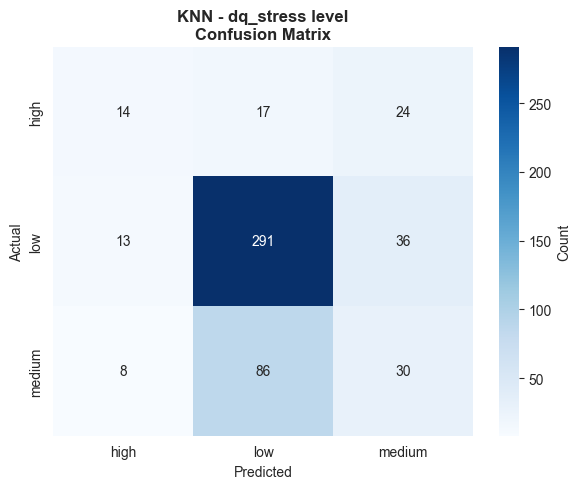

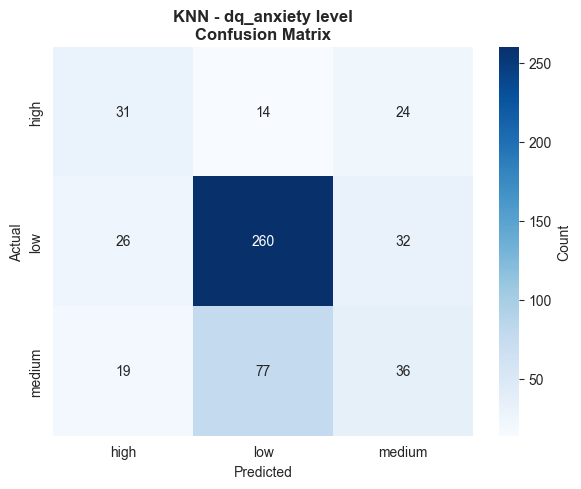


Confusion Matrices: Random Forest


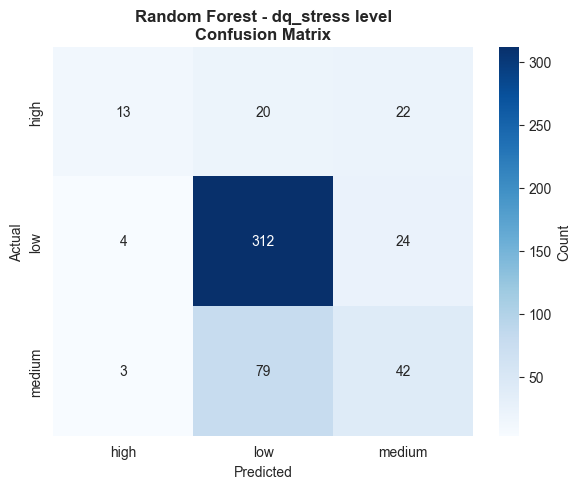

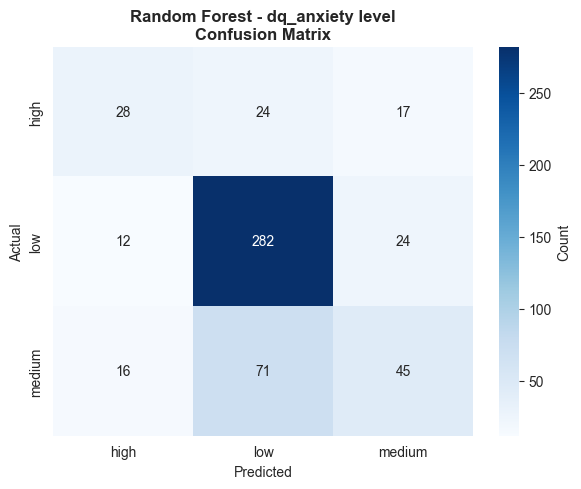


Confusion Matrices: SVM


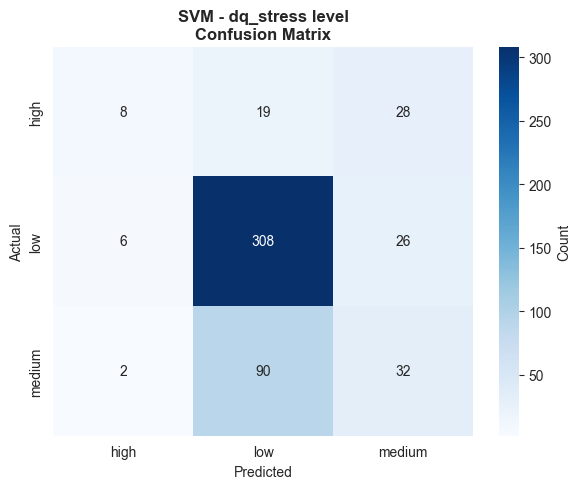

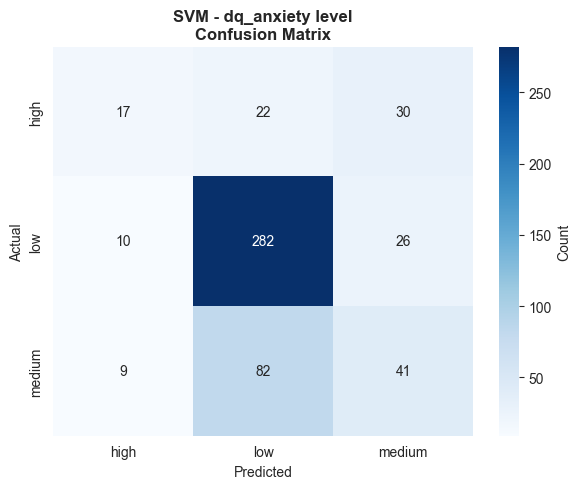


Confusion Matrices: Logistic Regression


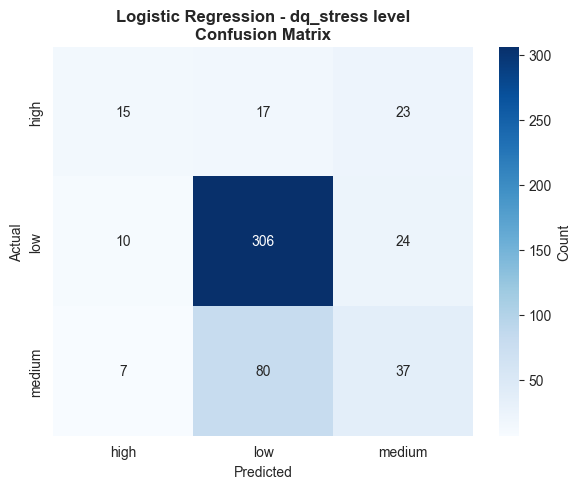

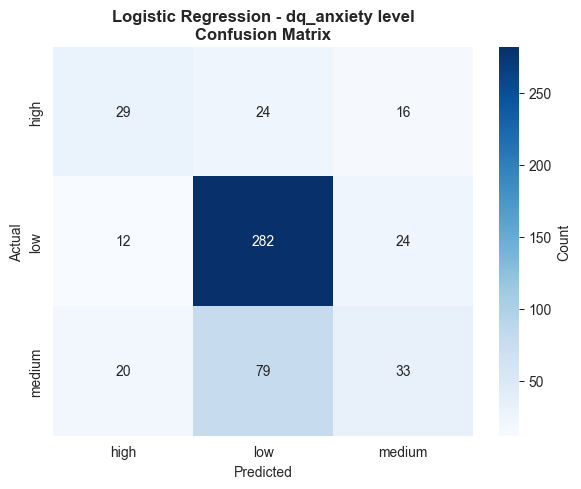

In [18]:
# Store predictions for confusion matrices
all_predictions = {}

# Re-run models to store predictions (or we can refactor to store them earlier)
models_config = [
    ("KNN", KNeighborsClassifier(), True),  # (name, model, needs_standardization)
    ("Random Forest", RandomForestClassifier(random_state=SEED), False),
    ("SVM", SVC(random_state=SEED), True),
    ("Logistic Regression", LogisticRegression(random_state=SEED, max_iter=1000), True),
]

for model_name, model, needs_std in models_config:
    all_predictions[model_name] = {}
    
    for t in targets:
        ylab = f"{t}_tplus1_class"
        
        # Add target-derived features
        feat_list = base_feats.copy()
        feat_list += [f"{t}_t", f"{t}_lag1", f"{t}_ma7"]
        feat_list = [f for f in feat_list if f in train.columns]
        
        # Prepare data
        tr_df, Xtr, ytr = take_xy_class(train, ylab, feat_list)
        te_df, Xte, yte = take_xy_class(test, ylab, feat_list)
        
        if len(tr_df) == 0 or len(te_df) == 0:
            continue
        
        # Standardize if needed
        if needs_std:
            mu, sd = fit_stats(Xtr)
            Xtr_s = apply_stats(Xtr, mu, sd)
            Xte_s = apply_stats(Xte, mu, sd)
            model.fit(Xtr_s, ytr)
            pred = model.predict(Xte_s)
        else:
            model.fit(Xtr, ytr)
            pred = model.predict(Xte)
        
        all_predictions[model_name][t] = {"y_true": yte, "y_pred": pred}

# Display confusion matrices
labels = ["high", "low", "medium"]  # Sort alphabetically for consistency

for model_name in all_predictions.keys():
    print(f"\n{'='*60}")
    print(f"Confusion Matrices: {model_name}")
    print(f"{'='*60}")
    
    for t in targets:
        if t not in all_predictions[model_name]:
            continue
        
        y_true = all_predictions[model_name][t]["y_true"]
        y_pred = all_predictions[model_name][t]["y_pred"]
        
        # Get unique labels present in data
        unique_labels = sorted(set(y_true) | set(y_pred))
        
        cm = confusion_matrix(y_true, y_pred, labels=unique_labels)
        
        fig, ax = plt.subplots(figsize=(6, 5))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                    xticklabels=unique_labels, yticklabels=unique_labels,
                    ax=ax, cbar_kws={'label': 'Count'})
        ax.set_title(f'{model_name} - {t}\nConfusion Matrix', fontsize=12, fontweight='bold')
        ax.set_xlabel('Predicted', fontsize=10)
        ax.set_ylabel('Actual', fontsize=10)
        plt.tight_layout()
        plt.show()


## 14.1 Best Model Confusion Matrices

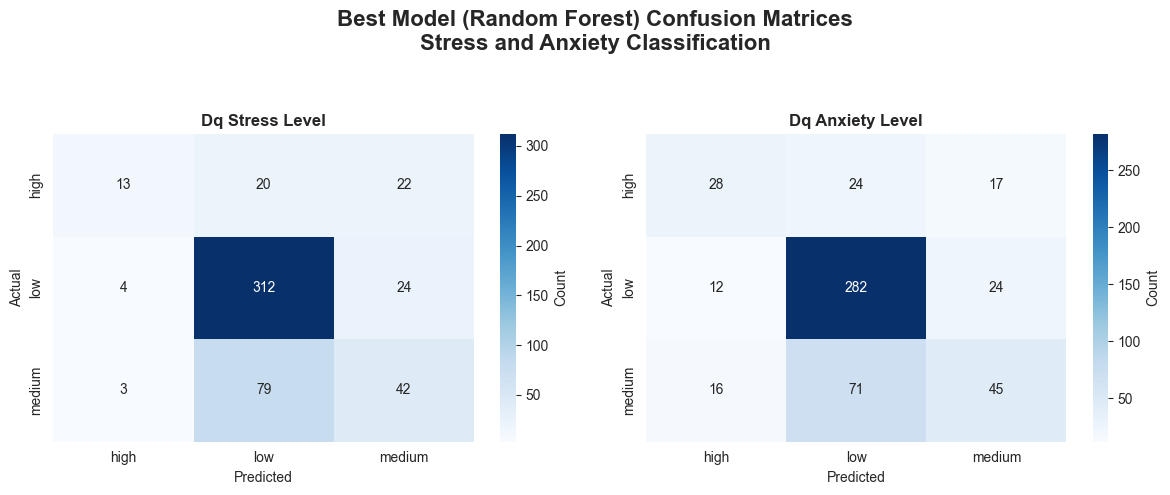

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

model_name = "Random Forest"
targets_to_show = ["dq_stress level", "dq_anxiety level"]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for i, t in enumerate(targets_to_show):

    ax = axes[i]

    y_true = all_predictions[model_name][t]["y_true"]
    y_pred = all_predictions[model_name][t]["y_pred"]

    labels = sorted(set(y_true) | set(y_pred))
    cm = confusion_matrix(y_true, y_pred, labels=labels)

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=labels,
        yticklabels=labels,
        ax=ax,
        cbar=True,
        cbar_kws={"label": "Count"}
    )

    ax.set_title(f"{t.replace('_', ' ').title()}", fontsize=12, fontweight="bold")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

# Global title
fig.suptitle(
    "Best Model (Random Forest) Confusion Matrices\nStress and Anxiety Classification",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout(rect=[0, 0, 1, 0.92])

# Save for LaTeX
plt.savefig("random_forest_best_confusion_matrices.pdf", dpi=300, bbox_inches="tight")

plt.show()


## 15. Model Comparison Charts


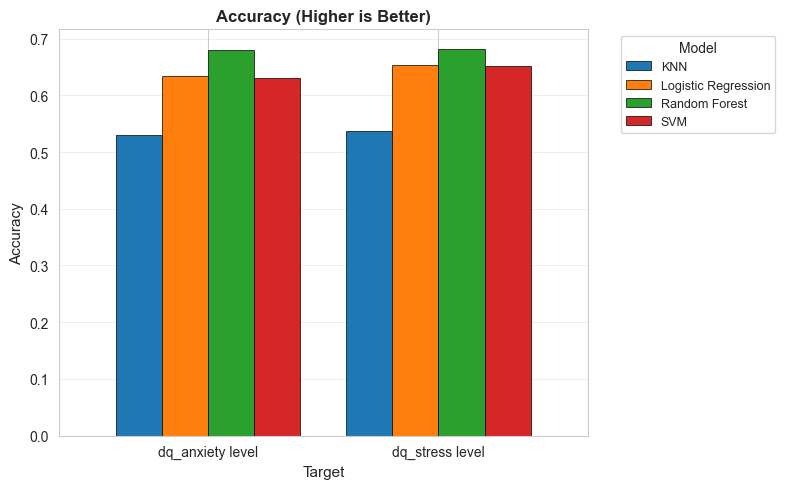

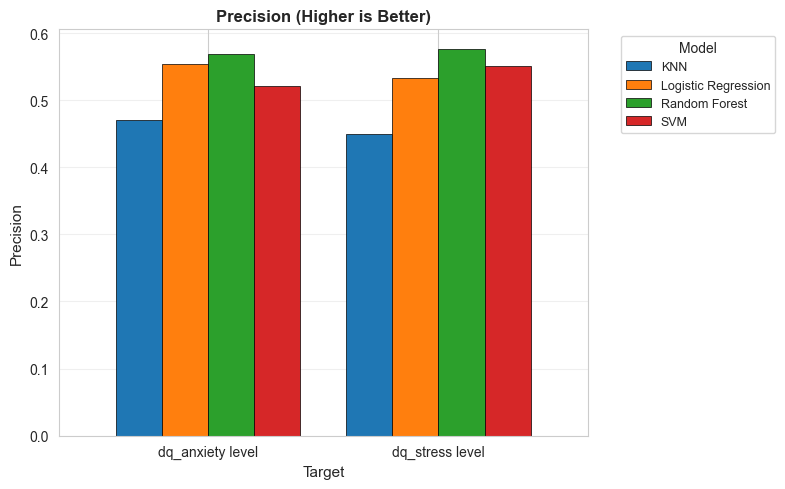

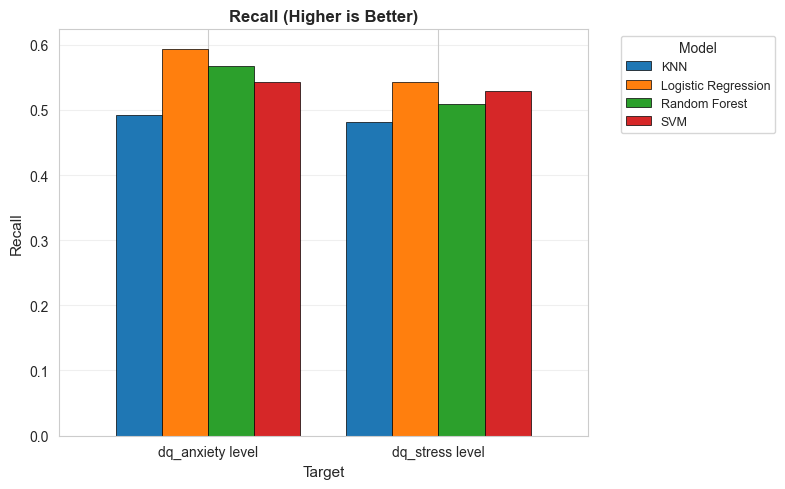

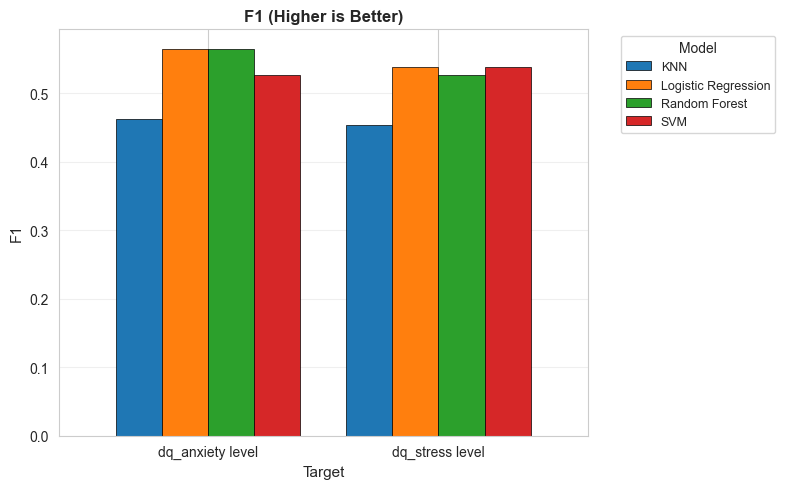

In [20]:
# Essential bar comparison charts (separate figures for each metric)
metrics = ['Accuracy', 'Precision', 'Recall', 'F1']
for metric in metrics:
    fig, ax = plt.subplots(figsize=(8, 5))
    pivot_data = all_results.pivot(index="target", columns="model", values=metric)
    
    pivot_data.plot(kind='bar', ax=ax, width=0.8, edgecolor='black', linewidth=0.5)
    ax.set_title(f'{metric} (Higher is Better)', 
                 fontsize=12, fontweight='bold')
    ax.set_ylabel(metric, fontsize=11)
    ax.set_xlabel('Target', fontsize=11)
    ax.legend(title='Model', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
    ax.grid(axis='y', alpha=0.3)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
    
    plt.tight_layout()
    plt.show()


## 16. Model Performance Heatmaps


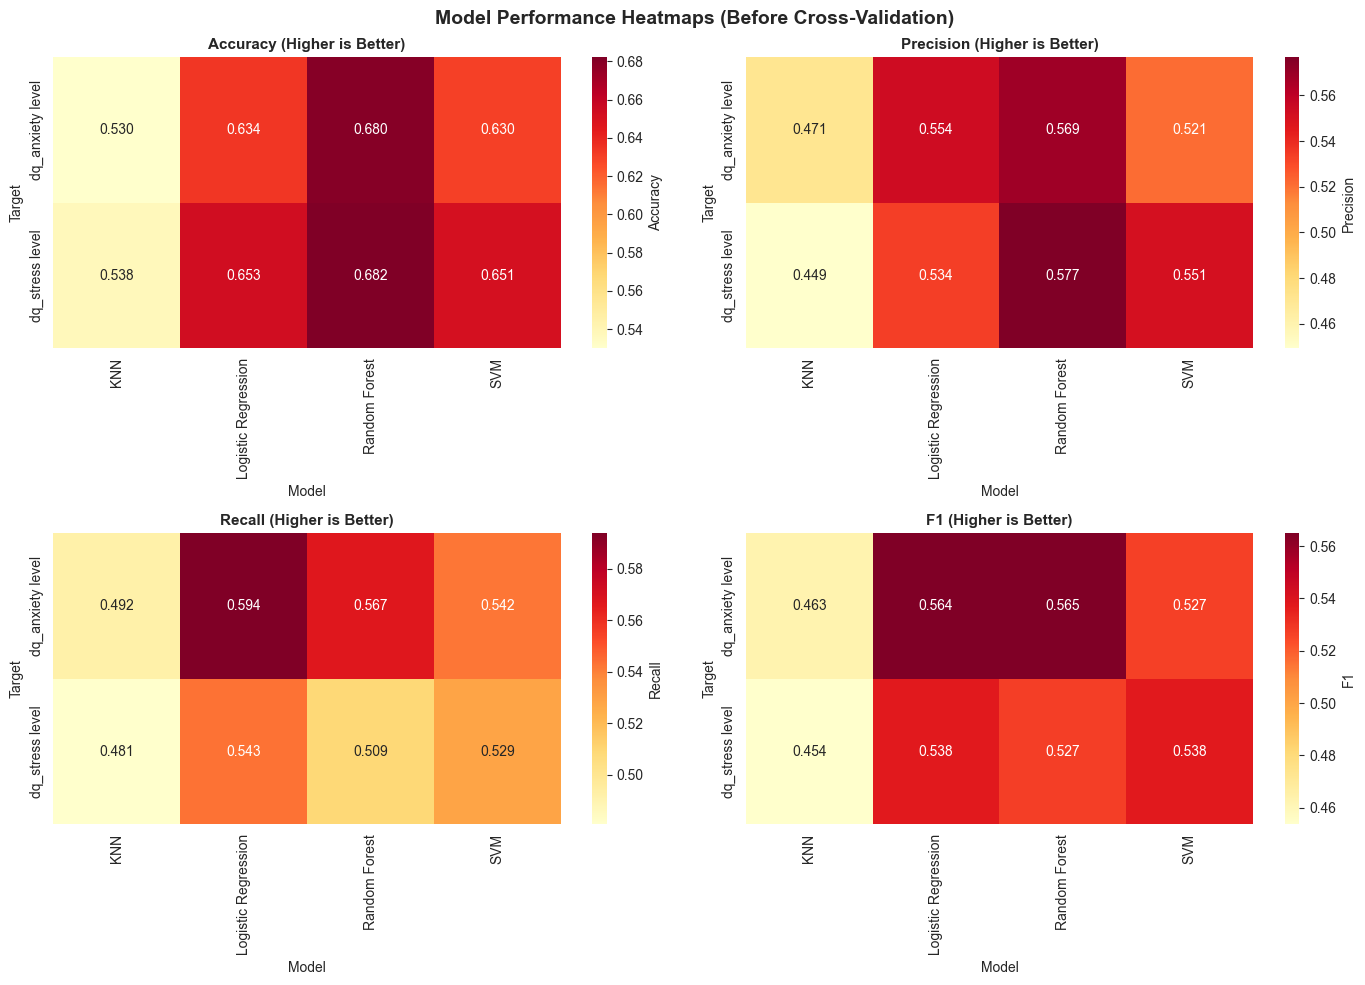

In [21]:
# Create heatmap of performance metrics
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Model Performance Heatmaps (Before Cross-Validation)', fontsize=14, fontweight='bold')

metrics = ['Accuracy', 'Precision', 'Recall', 'F1']
for idx, metric in enumerate(metrics):
    ax = axes[idx // 2, idx % 2]
    pivot_data = all_results.pivot(index="target", columns="model", values=metric)
    
    sns.heatmap(pivot_data, annot=True, fmt='.3f', cmap='YlOrRd', 
                ax=ax, cbar_kws={'label': metric})
    ax.set_title(f'{metric} (Higher is Better)', fontsize=11, fontweight='bold')
    ax.set_xlabel('Model', fontsize=10)
    ax.set_ylabel('Target', fontsize=10)

plt.tight_layout()
plt.show()


## 17. Best Model Summary


In [22]:
# Final summary with best model per metric per target (before Cross-Validation)
print("=== Best Model per Metric per Target (Before Cross-Validation) ===\n")

for metric in ['Accuracy', 'Precision', 'Recall', 'F1', 'Accuracy_Within_One']:
    print(f"{metric}:")
    pivot = all_results.pivot(index="target", columns="model", values=metric)
    for target in pivot.index:
        best_model = pivot.loc[target].idxmax()
        best_value = pivot.loc[target, best_model]
        print(f"  {target}: {best_model} ({best_value:.3f})")
    print()

=== Best Model per Metric per Target (Before Cross-Validation) ===

Accuracy:
  dq_anxiety level: Random Forest (0.680)
  dq_stress level: Random Forest (0.682)

Precision:
  dq_anxiety level: Random Forest (0.569)
  dq_stress level: Random Forest (0.577)

Recall:
  dq_anxiety level: Logistic Regression (0.594)
  dq_stress level: Logistic Regression (0.543)

F1:
  dq_anxiety level: Random Forest (0.565)
  dq_stress level: Logistic Regression (0.538)

Accuracy_Within_One:
  dq_anxiety level: Random Forest (0.942)
  dq_stress level: SVM (0.958)



## 18. Running same models using Cross-Validation


In [23]:
# Time-series cross-validation for all classifiers
cv_n_splits = 5
cv_results = []

# Define models configuration (same as in confusion matrices)
models_config = [
    ("KNN", lambda: KNeighborsClassifier(), True),  # Use lambda to create fresh instance each time
    ("Random Forest", lambda: RandomForestClassifier(random_state=SEED), False),
    ("SVM", lambda: SVC(random_state=SEED), True),
    ("Logistic Regression", lambda: LogisticRegression(random_state=SEED, max_iter=1000), True),
]

for model_name, model_factory, needs_std in models_config:
    for t in targets:
        ylab = f"{t}_tplus1_class"
        
        # Add target-derived features
        feat_list = base_feats.copy()
        feat_list += [f"{t}_t", f"{t}_lag1", f"{t}_ma7"]
        feat_list = [f for f in feat_list if f in train.columns]
        
        # Prepare full training data
        T = train.dropna(subset=[ylab] + feat_list).copy()
        
        if len(T) < 10:
            print(f"Skipping {model_name} - {t}: insufficient data ({len(T)} rows)")
            continue
        
        # TimeSeriesSplit
        udates = np.unique(T["date"].values)
        n_splits = min(cv_n_splits, max(2, len(udates) // 10))
        tscv = TimeSeriesSplit(n_splits=n_splits)
        
        X = T[feat_list].astype(float)
        y = T[ylab].astype(str)
        
        fold = 0
        fold_metrics = {"Accuracy": [], "Precision": [], "Recall": [], "F1": [], "Accuracy_Within_One": []}
        
        for tr_idx, va_idx in tscv.split(X):
            fold += 1
            Xtr, Xva = X.iloc[tr_idx], X.iloc[va_idx]
            ytr, yva = y.iloc[tr_idx], y.iloc[va_idx]
            
            if len(Xtr) == 0 or len(Xva) == 0:
                continue
            
            # Create fresh model instance for this fold
            model = model_factory()
            
            # Standardize if needed
            if needs_std:
                mu = Xtr.mean(0)
                sd = Xtr.std(0).replace(0, 1.0)
                Xtr_s = (Xtr - mu) / sd
                Xva_s = (Xva - mu) / sd
                model.fit(Xtr_s, ytr)
                pred = model.predict(Xva_s)
            else:
                model.fit(Xtr, ytr)
                pred = model.predict(Xva)
            
            fold_metrics["Accuracy"].append(accuracy(yva, pred))
            fold_metrics["Precision"].append(precision_macro(yva, pred))
            fold_metrics["Recall"].append(recall_macro(yva, pred))
            fold_metrics["F1"].append(f1_macro(yva, pred))
            fold_metrics["Accuracy_Within_One"].append(accuracy_within_one(yva, pred))
        
        # Calculate mean ± std
        if len(fold_metrics["Accuracy"]) > 0:
            cv_results.append({
                "target": t,
                "model": model_name,
                "Accuracy_mean": np.mean(fold_metrics["Accuracy"]),
                "Accuracy_std": np.std(fold_metrics["Accuracy"]),
                "Precision_mean": np.mean(fold_metrics["Precision"]),
                "Precision_std": np.std(fold_metrics["Precision"]),
                "Recall_mean": np.mean(fold_metrics["Recall"]),
                "Recall_std": np.std(fold_metrics["Recall"]),
                "F1_mean": np.mean(fold_metrics["F1"]),
                "F1_std": np.std(fold_metrics["F1"]),
                "Accuracy_Within_One_mean": np.mean(fold_metrics["Accuracy_Within_One"]),
                "Accuracy_Within_One_std": np.std(fold_metrics["Accuracy_Within_One"]),
            })
            print(f"CV completed: {model_name} - {t} ({len(fold_metrics['Accuracy'])} folds)")
        else:
            print(f"Warning: No folds completed for {model_name} - {t}")

cv_df = pd.DataFrame(cv_results)

# Display CV summary
if not cv_df.empty:
    print("=== Cross-Validation Results (mean ± std) ===")
    for metric in ["Accuracy", "Precision", "Recall", "F1", "Accuracy_Within_One"]:
        print(f"\n{metric}:")
        # Create pivot for mean values
        mean_pivot = cv_df.pivot(index="target", columns="model", values=f"{metric}_mean")
        std_pivot = cv_df.pivot(index="target", columns="model", values=f"{metric}_std")
        
        # Combine mean ± std
        display_df = pd.DataFrame(index=mean_pivot.index, columns=mean_pivot.columns)
        for target in mean_pivot.index:
            for model in mean_pivot.columns:
                if pd.notna(mean_pivot.loc[target, model]):
                    mean_val = mean_pivot.loc[target, model]
                    std_val = std_pivot.loc[target, model] if pd.notna(std_pivot.loc[target, model]) else 0
                    display_df.loc[target, model] = f"{mean_val:.3f} ± {std_val:.3f}"
        display(display_df)
else:
    print("No CV results available")
    print(f"cv_df shape: {cv_df.shape if 'cv_df' in locals() else 'not defined'}")
    print(f"Number of CV results collected: {len(cv_results)}")

CV completed: KNN - dq_stress level (5 folds)
CV completed: KNN - dq_anxiety level (5 folds)
CV completed: Random Forest - dq_stress level (5 folds)
CV completed: Random Forest - dq_anxiety level (5 folds)
CV completed: SVM - dq_stress level (5 folds)
CV completed: SVM - dq_anxiety level (5 folds)
CV completed: Logistic Regression - dq_stress level (5 folds)
CV completed: Logistic Regression - dq_anxiety level (5 folds)
=== Cross-Validation Results (mean ± std) ===

Accuracy:


model,KNN,Logistic Regression,Random Forest,SVM
target,,,,
dq_anxiety level,0.617 ± 0.042,0.643 ± 0.052,0.682 ± 0.053,0.659 ± 0.060
dq_stress level,0.656 ± 0.044,0.696 ± 0.070,0.715 ± 0.064,0.678 ± 0.081



Precision:


model,KNN,Logistic Regression,Random Forest,SVM
target,,,,
dq_anxiety level,0.542 ± 0.049,0.587 ± 0.050,0.649 ± 0.044,0.659 ± 0.050
dq_stress level,0.598 ± 0.023,0.659 ± 0.040,0.698 ± 0.043,0.654 ± 0.069



Recall:


model,KNN,Logistic Regression,Random Forest,SVM
target,,,,
dq_anxiety level,0.509 ± 0.054,0.543 ± 0.056,0.586 ± 0.075,0.527 ± 0.085
dq_stress level,0.542 ± 0.036,0.603 ± 0.040,0.612 ± 0.050,0.544 ± 0.078



F1:


model,KNN,Logistic Regression,Random Forest,SVM
target,,,,
dq_anxiety level,0.510 ± 0.059,0.546 ± 0.060,0.597 ± 0.084,0.536 ± 0.111
dq_stress level,0.555 ± 0.036,0.619 ± 0.041,0.635 ± 0.058,0.558 ± 0.105



Accuracy_Within_One:


model,KNN,Logistic Regression,Random Forest,SVM
target,,,,
dq_anxiety level,0.908 ± 0.020,0.934 ± 0.016,0.937 ± 0.025,0.926 ± 0.035
dq_stress level,0.936 ± 0.016,0.959 ± 0.023,0.956 ± 0.025,0.939 ± 0.041


## 19. Finaly Summary with CV including baselines

In [24]:
# Cross-validation for ALL models (learned + baselines)
# Also stores out-of-fold predictions for CV confusion matrices

cv_n_splits = 5
cv_all_results = []
cv_all_predictions = {}

def init_fold_metrics():
    return {
        "Accuracy": [],
        "Precision": [],
        "Recall": [],
        "F1": [],
        "Accuracy_Within_One": []
    }

# ------------------------------------------------------------
# 1) Learned models (same logic as point 15, but storing OOF preds)
# ------------------------------------------------------------
cv_models_config = [
    ("KNN", lambda: KNeighborsClassifier(), True),
    ("Random Forest", lambda: RandomForestClassifier(random_state=SEED), False),
    ("SVM", lambda: SVC(random_state=SEED), True),
    ("Logistic Regression", lambda: LogisticRegression(random_state=SEED, max_iter=1000), True),
]

for model_name, model_factory, needs_std in cv_models_config:
    cv_all_predictions[model_name] = {}
    
    for t in targets:
        ylab = f"{t}_tplus1_class"
        
        # Same feature construction used in the rest of the notebook
        feat_list = base_feats.copy()
        feat_list += [f"{t}_t", f"{t}_lag1", f"{t}_ma7"]
        feat_list = [f for f in feat_list if f in train.columns]
        
        T = train.dropna(subset=[ylab] + feat_list).copy()
        
        if len(T) < 10:
            print(f"Skipping {model_name} - {t}: insufficient data ({len(T)} rows)")
            continue
        
        T = T.sort_values("date").reset_index(drop=True)
        X = T[feat_list].astype(float)
        y = T[ylab].astype(str)
        
        udates = np.unique(T["date"].values)
        n_splits = min(cv_n_splits, max(2, len(udates) // 10))
        tscv = TimeSeriesSplit(n_splits=n_splits)
        
        fold_metrics = init_fold_metrics()
        y_true_all = []
        y_pred_all = []
        
        fold = 0
        for tr_idx, va_idx in tscv.split(X):
            fold += 1
            
            Xtr, Xva = X.iloc[tr_idx], X.iloc[va_idx]
            ytr, yva = y.iloc[tr_idx], y.iloc[va_idx]
            
            if len(Xtr) == 0 or len(Xva) == 0:
                continue
            
            model = model_factory()
            
            # Same style as your current point 15
            if needs_std:
                mu = Xtr.mean(0)
                sd = Xtr.std(0).replace(0, 1.0)
                Xtr_s = (Xtr - mu) / sd
                Xva_s = (Xva - mu) / sd
                
                model.fit(Xtr_s, ytr)
                pred = model.predict(Xva_s)
            else:
                model.fit(Xtr, ytr)
                pred = model.predict(Xva)
            
            fold_metrics["Accuracy"].append(accuracy(yva, pred))
            fold_metrics["Precision"].append(precision_macro(yva, pred))
            fold_metrics["Recall"].append(recall_macro(yva, pred))
            fold_metrics["F1"].append(f1_macro(yva, pred))
            fold_metrics["Accuracy_Within_One"].append(accuracy_within_one(yva, pred))
            
            y_true_all.extend(yva.tolist())
            y_pred_all.extend(pred.tolist())
        
        if len(fold_metrics["Accuracy"]) > 0:
            cv_all_results.append({
                "target": t,
                "model": model_name,
                "Accuracy_mean": np.mean(fold_metrics["Accuracy"]),
                "Accuracy_std": np.std(fold_metrics["Accuracy"]),
                "Precision_mean": np.mean(fold_metrics["Precision"]),
                "Precision_std": np.std(fold_metrics["Precision"]),
                "Recall_mean": np.mean(fold_metrics["Recall"]),
                "Recall_std": np.std(fold_metrics["Recall"]),
                "F1_mean": np.mean(fold_metrics["F1"]),
                "F1_std": np.std(fold_metrics["F1"]),
                "Accuracy_Within_One_mean": np.mean(fold_metrics["Accuracy_Within_One"]),
                "Accuracy_Within_One_std": np.std(fold_metrics["Accuracy_Within_One"]),
            })
            
            cv_all_predictions[model_name][t] = {
                "y_true": np.array(y_true_all),
                "y_pred": np.array(y_pred_all)
            }
            
            print(f"CV completed: {model_name} - {t} ({len(fold_metrics['Accuracy'])} folds)")
        else:
            print(f"Warning: No folds completed for {model_name} - {t}")

# ------------------------------------------------------------
# 2) Baseline models with the SAME TimeSeriesSplit
# ------------------------------------------------------------
baseline_names = ["Most Frequent Class", "Most Frequent Last 7 Days", "Random"]

for baseline_name in baseline_names:
    cv_all_predictions[baseline_name] = {}

for t in targets:
    ylab = f"{t}_tplus1_class"
    
    feat_list = base_feats.copy()
    feat_list += [f"{t}_t", f"{t}_lag1", f"{t}_ma7"]
    feat_list = [f for f in feat_list if f in train.columns]
    
    T = train.dropna(subset=[ylab] + feat_list).copy()
    
    if len(T) < 10:
        print(f"Skipping baselines - {t}: insufficient data ({len(T)} rows)")
        continue
    
    T = T.sort_values("date").reset_index(drop=True)
    X = T[feat_list].astype(float)
    y = T[ylab].astype(str)
    dates = T["date"].reset_index(drop=True)
    
    udates = np.unique(T["date"].values)
    n_splits = min(cv_n_splits, max(2, len(udates) // 10))
    tscv = TimeSeriesSplit(n_splits=n_splits)
    
    baseline_fold_metrics = {
        "Most Frequent Class": init_fold_metrics(),
        "Most Frequent Last 7 Days": init_fold_metrics(),
        "Random": init_fold_metrics()
    }
    
    baseline_y_true = {
        "Most Frequent Class": [],
        "Most Frequent Last 7 Days": [],
        "Random": []
    }
    
    baseline_y_pred = {
        "Most Frequent Class": [],
        "Most Frequent Last 7 Days": [],
        "Random": []
    }
    
    fold = 0
    for tr_idx, va_idx in tscv.split(X):
        fold += 1
        
        ytr = y.iloc[tr_idx].reset_index(drop=True)
        yva = y.iloc[va_idx].reset_index(drop=True)
        dates_tr = dates.iloc[tr_idx].reset_index(drop=True)
        dates_va = dates.iloc[va_idx].reset_index(drop=True)
        
        if len(ytr) == 0 or len(yva) == 0:
            continue
        
        classes = sorted(ytr.unique())
        
        # Baseline 1: Most Frequent Class
        most_frequent_class = ytr.value_counts().index[0]
        pred_mf = np.array([most_frequent_class] * len(yva))
        
        # Baseline 2: Most Frequent Last 7 Days
        tr_df_fold = pd.DataFrame({
            "date": dates_tr,
            ylab: ytr
        }).sort_values("date").reset_index(drop=True)
        
        pred_mf7 = []
        for val_date in dates_va:
            train_window = tr_df_fold[tr_df_fold["date"] < val_date].tail(7)
            
            if len(train_window) > 0:
                window_classes = train_window[ylab].dropna()
                if len(window_classes) > 0:
                    pred_mf7.append(window_classes.value_counts().index[0])
                else:
                    pred_mf7.append(most_frequent_class)
            else:
                pred_mf7.append(most_frequent_class)
        
        pred_mf7 = np.array(pred_mf7)
        
        # Baseline 3: Random
        rng = np.random.default_rng(SEED + fold)
        pred_random = rng.choice(classes, size=len(yva))
        
        baseline_preds = {
            "Most Frequent Class": pred_mf,
            "Most Frequent Last 7 Days": pred_mf7,
            "Random": pred_random
        }
        
        for model_name, pred in baseline_preds.items():
            baseline_fold_metrics[model_name]["Accuracy"].append(accuracy(yva, pred))
            baseline_fold_metrics[model_name]["Precision"].append(precision_macro(yva, pred))
            baseline_fold_metrics[model_name]["Recall"].append(recall_macro(yva, pred))
            baseline_fold_metrics[model_name]["F1"].append(f1_macro(yva, pred))
            baseline_fold_metrics[model_name]["Accuracy_Within_One"].append(accuracy_within_one(yva, pred))
            
            baseline_y_true[model_name].extend(yva.tolist())
            baseline_y_pred[model_name].extend(pred.tolist())
    
    for model_name in baseline_names:
        if len(baseline_fold_metrics[model_name]["Accuracy"]) > 0:
            cv_all_results.append({
                "target": t,
                "model": model_name,
                "Accuracy_mean": np.mean(baseline_fold_metrics[model_name]["Accuracy"]),
                "Accuracy_std": np.std(baseline_fold_metrics[model_name]["Accuracy"]),
                "Precision_mean": np.mean(baseline_fold_metrics[model_name]["Precision"]),
                "Precision_std": np.std(baseline_fold_metrics[model_name]["Precision"]),
                "Recall_mean": np.mean(baseline_fold_metrics[model_name]["Recall"]),
                "Recall_std": np.std(baseline_fold_metrics[model_name]["Recall"]),
                "F1_mean": np.mean(baseline_fold_metrics[model_name]["F1"]),
                "F1_std": np.std(baseline_fold_metrics[model_name]["F1"]),
                "Accuracy_Within_One_mean": np.mean(baseline_fold_metrics[model_name]["Accuracy_Within_One"]),
                "Accuracy_Within_One_std": np.std(baseline_fold_metrics[model_name]["Accuracy_Within_One"]),
            })
            
            cv_all_predictions[model_name][t] = {
                "y_true": np.array(baseline_y_true[model_name]),
                "y_pred": np.array(baseline_y_pred[model_name])
            }
            
            print(f"CV completed: {model_name} - {t} ({len(baseline_fold_metrics[model_name]['Accuracy'])} folds)")
        else:
            print(f"Warning: No folds completed for {model_name} - {t}")

cv_all_df = pd.DataFrame(cv_all_results)

# Display CV summary including baselines
if not cv_all_df.empty:
    print("=== Cross-Validation Results for ALL Models (mean ± std) ===")
    for metric in ["Accuracy", "Precision", "Recall", "F1", "Accuracy_Within_One"]:
        print(f"\n{metric}:")
        mean_pivot = cv_all_df.pivot(index="target", columns="model", values=f"{metric}_mean")
        std_pivot = cv_all_df.pivot(index="target", columns="model", values=f"{metric}_std")
        
        display_df = pd.DataFrame(index=mean_pivot.index, columns=mean_pivot.columns)
        for target in mean_pivot.index:
            for model in mean_pivot.columns:
                if pd.notna(mean_pivot.loc[target, model]):
                    mean_val = mean_pivot.loc[target, model]
                    std_val = std_pivot.loc[target, model] if pd.notna(std_pivot.loc[target, model]) else 0
                    display_df.loc[target, model] = f"{mean_val:.3f} ± {std_val:.3f}"
        
        display(display_df)
else:
    print("No CV results available")

CV completed: KNN - dq_stress level (5 folds)
CV completed: KNN - dq_anxiety level (5 folds)
CV completed: Random Forest - dq_stress level (5 folds)
CV completed: Random Forest - dq_anxiety level (5 folds)
CV completed: SVM - dq_stress level (5 folds)
CV completed: SVM - dq_anxiety level (5 folds)
CV completed: Logistic Regression - dq_stress level (5 folds)
CV completed: Logistic Regression - dq_anxiety level (5 folds)
CV completed: Most Frequent Class - dq_stress level (5 folds)
CV completed: Most Frequent Last 7 Days - dq_stress level (5 folds)
CV completed: Random - dq_stress level (5 folds)
CV completed: Most Frequent Class - dq_anxiety level (5 folds)
CV completed: Most Frequent Last 7 Days - dq_anxiety level (5 folds)
CV completed: Random - dq_anxiety level (5 folds)
=== Cross-Validation Results for ALL Models (mean ± std) ===

Accuracy:


model,KNN,Logistic Regression,Most Frequent Class,Most Frequent Last 7 Days,Random,Random Forest,SVM
target,,,,,,,
dq_anxiety level,0.616 ± 0.046,0.647 ± 0.051,0.565 ± 0.026,0.451 ± 0.147,0.330 ± 0.017,0.679 ± 0.059,0.663 ± 0.053
dq_stress level,0.656 ± 0.045,0.697 ± 0.067,0.590 ± 0.071,0.546 ± 0.137,0.330 ± 0.025,0.710 ± 0.068,0.686 ± 0.069



Precision:


model,KNN,Logistic Regression,Most Frequent Class,Most Frequent Last 7 Days,Random,Random Forest,SVM
target,,,,,,,
dq_anxiety level,0.542 ± 0.049,0.592 ± 0.048,0.188 ± 0.009,0.184 ± 0.058,0.330 ± 0.022,0.628 ± 0.080,0.662 ± 0.051
dq_stress level,0.595 ± 0.024,0.658 ± 0.037,0.197 ± 0.024,0.239 ± 0.077,0.330 ± 0.026,0.690 ± 0.044,0.668 ± 0.044



Recall:


model,KNN,Logistic Regression,Most Frequent Class,Most Frequent Last 7 Days,Random,Random Forest,SVM
target,,,,,,,
dq_anxiety level,0.507 ± 0.058,0.547 ± 0.058,0.333 ± 0.000,0.334 ± 0.001,0.332 ± 0.027,0.573 ± 0.085,0.535 ± 0.072
dq_stress level,0.545 ± 0.034,0.603 ± 0.039,0.333 ± 0.000,0.335 ± 0.004,0.322 ± 0.041,0.607 ± 0.046,0.555 ± 0.060



F1:


model,KNN,Logistic Regression,Most Frequent Class,Most Frequent Last 7 Days,Random,Random Forest,SVM
target,,,,,,,
dq_anxiety level,0.509 ± 0.063,0.552 ± 0.059,0.241 ± 0.007,0.203 ± 0.048,0.310 ± 0.020,0.583 ± 0.100,0.550 ± 0.088
dq_stress level,0.559 ± 0.033,0.618 ± 0.040,0.247 ± 0.018,0.235 ± 0.035,0.301 ± 0.039,0.633 ± 0.050,0.573 ± 0.078



Accuracy_Within_One:


model,KNN,Logistic Regression,Most Frequent Class,Most Frequent Last 7 Days,Random,Random Forest,SVM
target,,,,,,,
dq_anxiety level,0.908 ± 0.019,0.934 ± 0.012,0.823 ± 0.020,0.890 ± 0.091,0.768 ± 0.030,0.931 ± 0.022,0.931 ± 0.023
dq_stress level,0.936 ± 0.016,0.959 ± 0.023,0.844 ± 0.024,0.882 ± 0.061,0.764 ± 0.037,0.956 ± 0.020,0.944 ± 0.032


## 20. CV Evaluation Confusion Matrices


CROSS-VALIDATION CONFUSION MATRICES (OUT-OF-FOLD)

CV Confusion Matrices: KNN


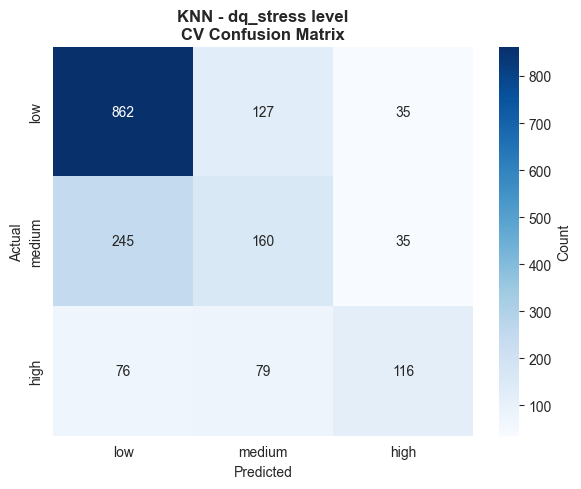

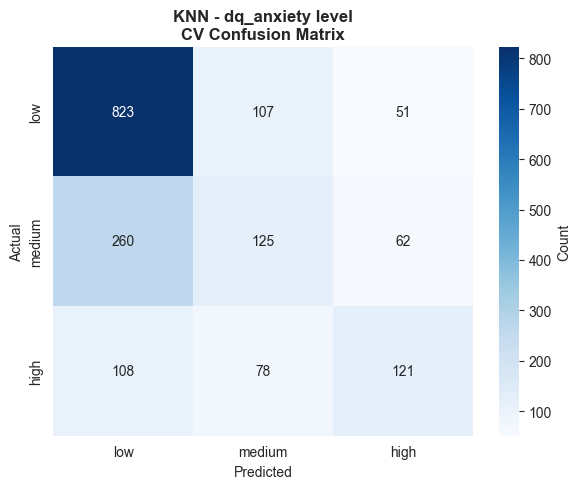


CV Confusion Matrices: Random Forest


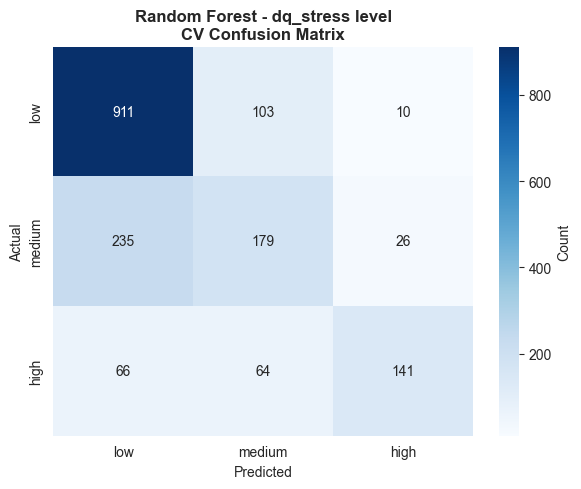

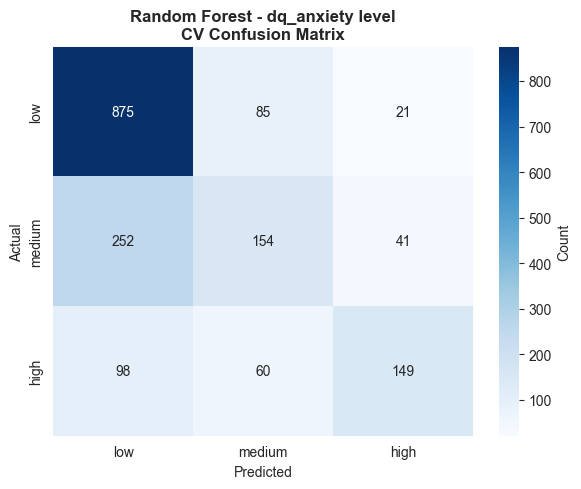


CV Confusion Matrices: SVM


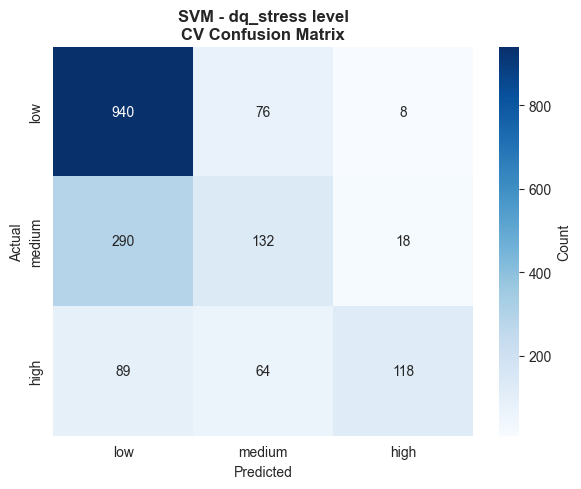

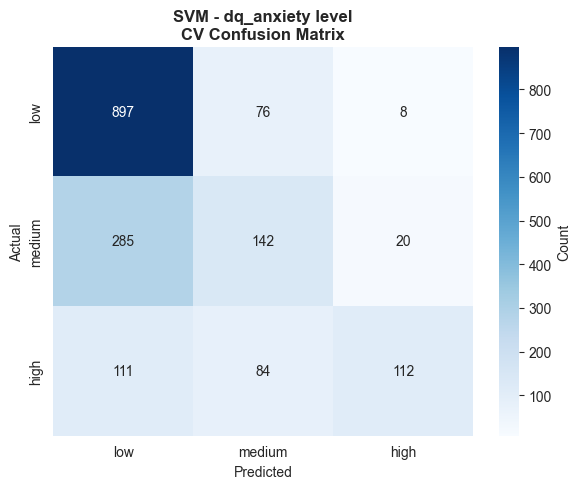


CV Confusion Matrices: Logistic Regression


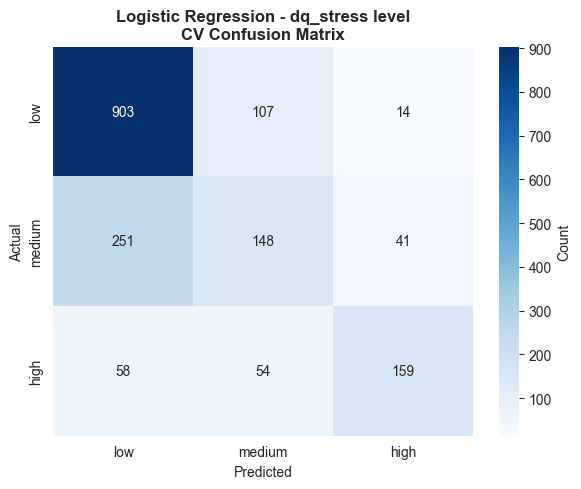

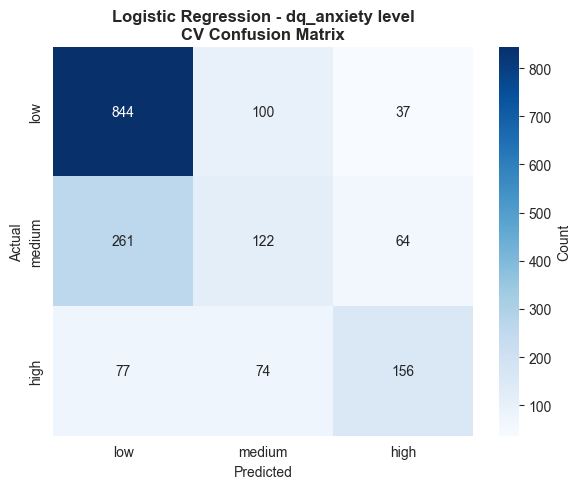


CV Confusion Matrices: Most Frequent Class


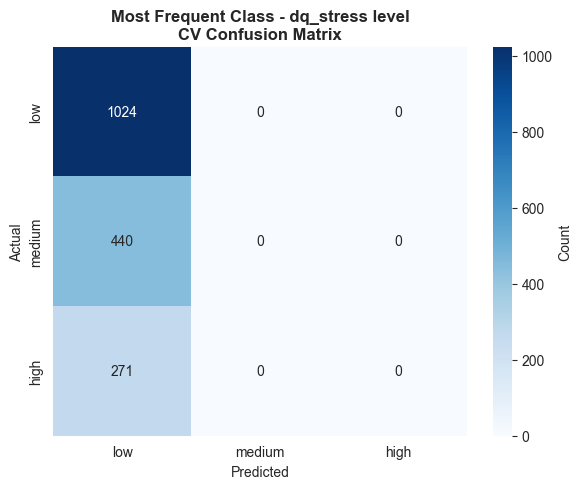

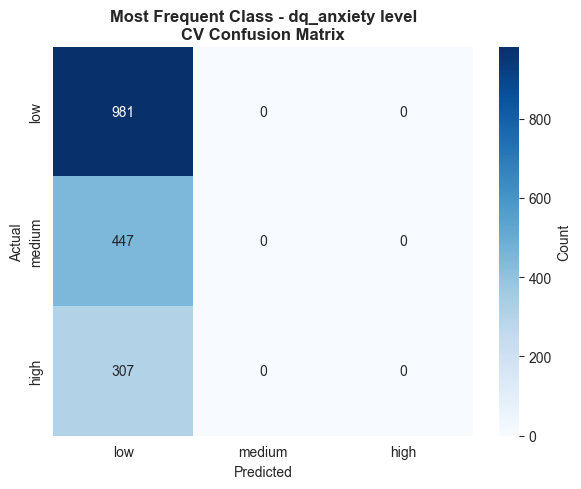


CV Confusion Matrices: Most Frequent Last 7 Days


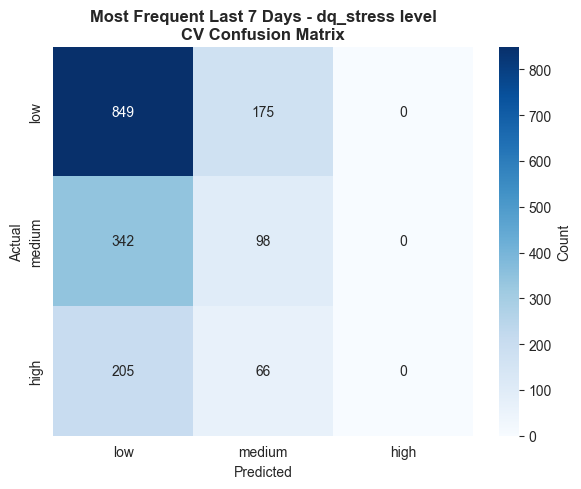

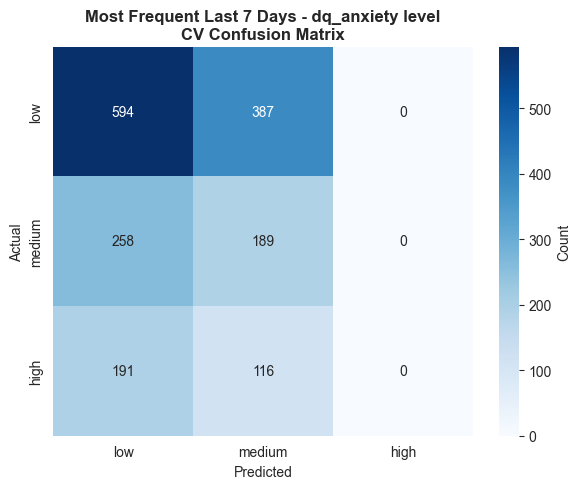


CV Confusion Matrices: Random


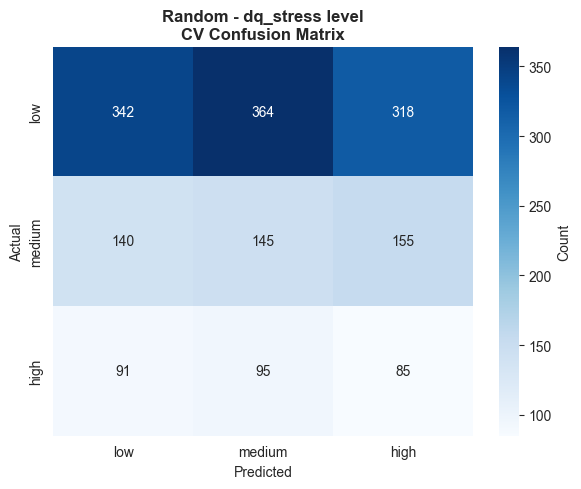

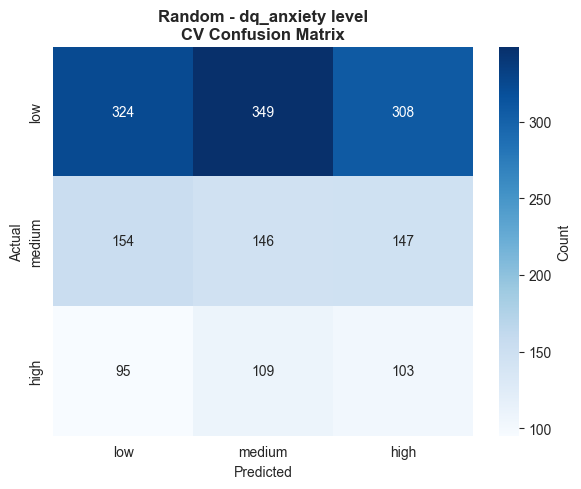


BEST MODEL CV CONFUSION MATRICES: Random Forest


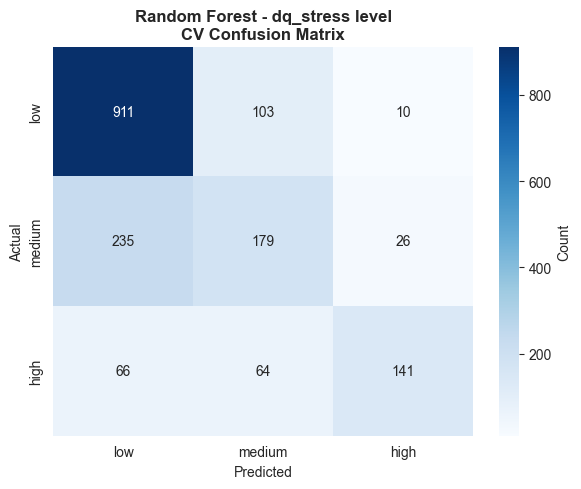

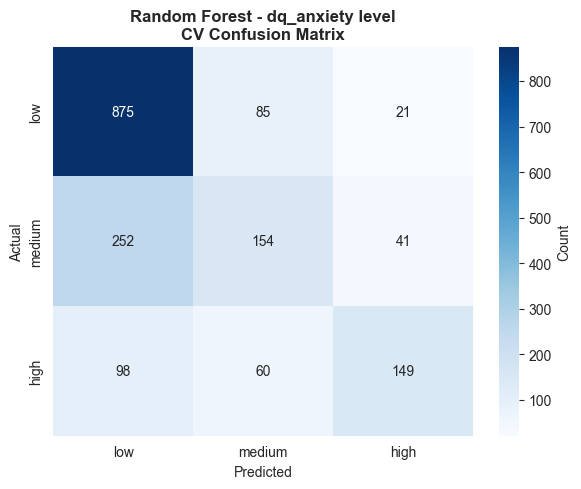

In [29]:
# Cross-validation confusion matrices (out-of-fold predictions)
import matplotlib.pyplot as plt

class_order = ["low", "medium", "high"]

print("\n" + "="*70)
print("CROSS-VALIDATION CONFUSION MATRICES (OUT-OF-FOLD)")
print("="*70)

for model_name in cv_all_predictions.keys():
    print(f"\n{'='*60}")
    print(f"CV Confusion Matrices: {model_name}")
    print(f"{'='*60}")
    
    for t in targets:
        if t not in cv_all_predictions[model_name]:
            continue
        
        y_true = cv_all_predictions[model_name][t]["y_true"]
        y_pred = cv_all_predictions[model_name][t]["y_pred"]
        
        present_labels = [lab for lab in class_order if (lab in set(y_true)) or (lab in set(y_pred))]
        cm = confusion_matrix(y_true, y_pred, labels=present_labels)
        
        fig, ax = plt.subplots(figsize=(6, 5))
        sns.heatmap(
            cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=present_labels,
            yticklabels=present_labels,
            ax=ax,
            cbar_kws={'label': 'Count'}
        )
        ax.set_title(f'{model_name} - {t}\nCV Confusion Matrix', fontsize=12, fontweight='bold')
        ax.set_xlabel('Predicted', fontsize=10)
        ax.set_ylabel('Actual', fontsize=10)
        plt.tight_layout()
        plt.show()

# ------------------------------------------------------------
# Best model confusion matrices again (Random Forest) using CV
# ------------------------------------------------------------
best_model_name = "Random Forest"

print("\n" + "="*70)
print(f"BEST MODEL CV CONFUSION MATRICES: {best_model_name}")
print("="*70)

if best_model_name in cv_all_predictions:
    for t in targets:
        if t not in cv_all_predictions[best_model_name]:
            continue
        
        y_true = cv_all_predictions[best_model_name][t]["y_true"]
        y_pred = cv_all_predictions[best_model_name][t]["y_pred"]
        
        present_labels = [lab for lab in class_order if (lab in set(y_true)) or (lab in set(y_pred))]
        cm = confusion_matrix(y_true, y_pred, labels=present_labels)
        
        fig, ax = plt.subplots(figsize=(6, 5))
        sns.heatmap(
            cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=present_labels,
            yticklabels=present_labels,
            ax=ax,
            cbar_kws={'label': 'Count'}
        )
        ax.set_title(f'{best_model_name} - {t}\nCV Confusion Matrix', fontsize=12, fontweight='bold')
        ax.set_xlabel('Predicted', fontsize=10)
        ax.set_ylabel('Actual', fontsize=10)
        plt.tight_layout()
        plt.show()
else:
    print(f"{best_model_name} not found in cv_all_predictions")

## 20.1 Best Model Confusion Matrices

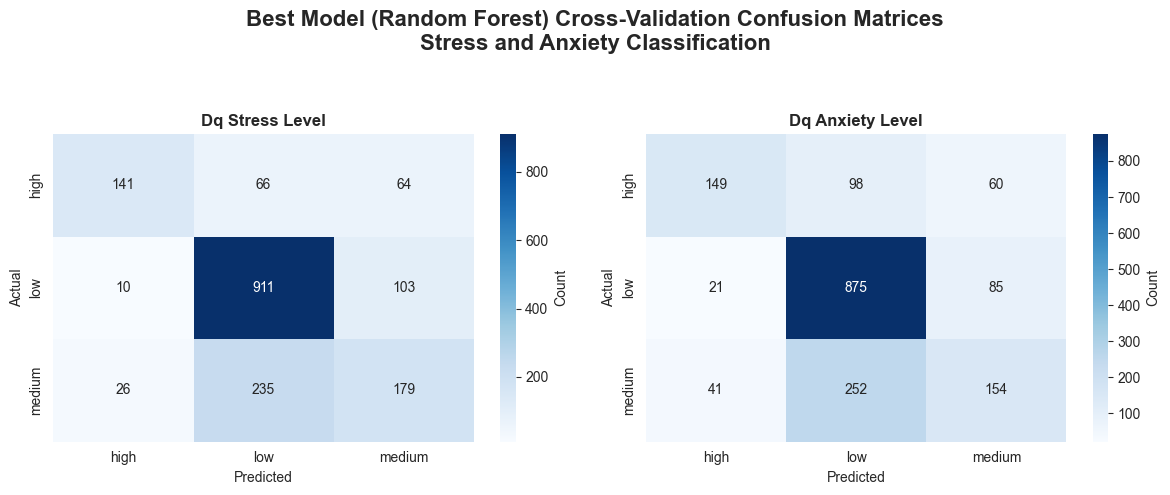

In [ ]:
model_name = "Random Forest"
targets_to_show = ["dq_stress level", "dq_anxiety level"]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for i, t in enumerate(targets_to_show):

    ax = axes[i]

    y_true = cv_all_predictions[model_name][t]["y_true"]
    y_pred = cv_all_predictions[model_name][t]["y_pred"]

    labels = sorted(set(y_true) | set(y_pred))
    cm = confusion_matrix(y_true, y_pred, labels=labels)

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=labels,
        yticklabels=labels,
        ax=ax,
        cbar=True,
        cbar_kws={"label": "Count"}
    )

    ax.set_title(f"{t.replace('_', ' ').title()}", fontsize=12, fontweight="bold")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

# Global title
fig.suptitle(
    "Best Model (Random Forest) Cross-Validation Confusion Matrices\nStress and Anxiety Classification",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout(rect=[0, 0, 1, 0.92])

# Save for LaTeX
plt.savefig("random_forest_best_confusion_matrices_cv.pdf", dpi=300, bbox_inches="tight")

plt.show()

## 21. Cross-Validation Comparison Charts


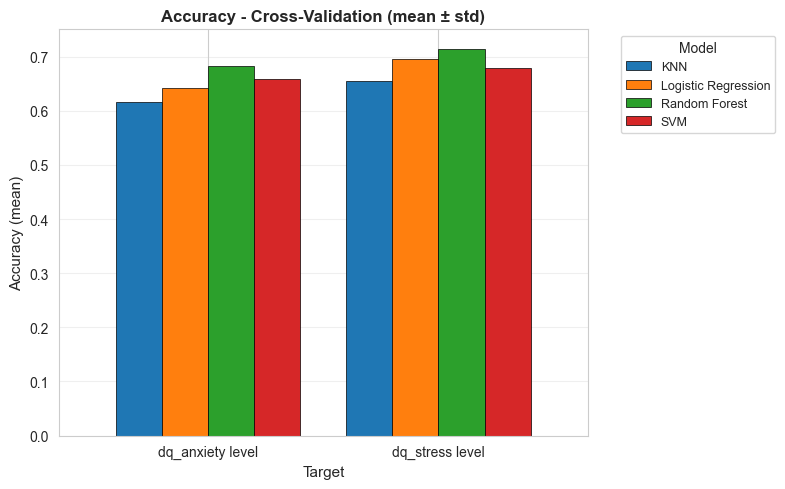

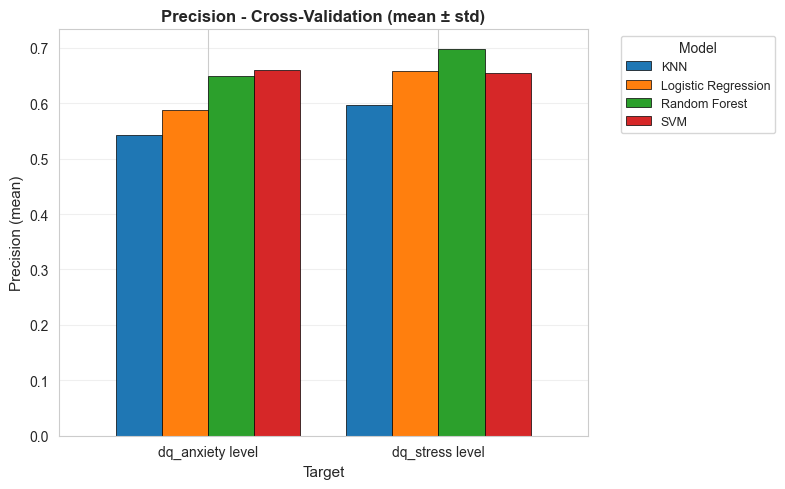

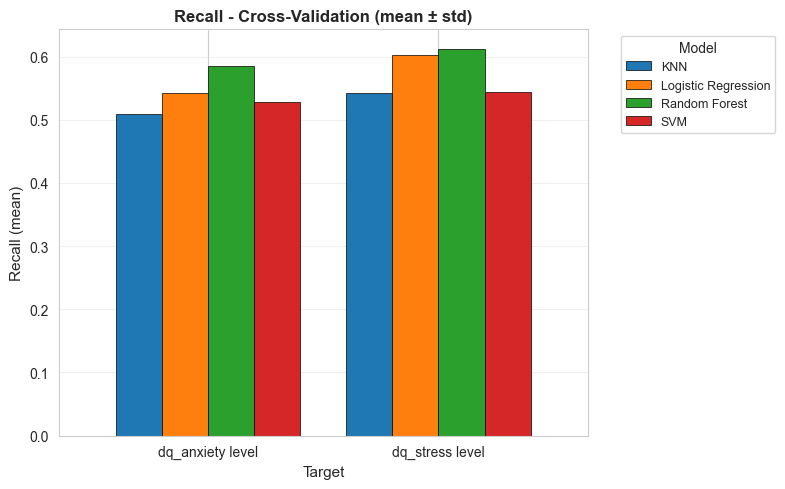

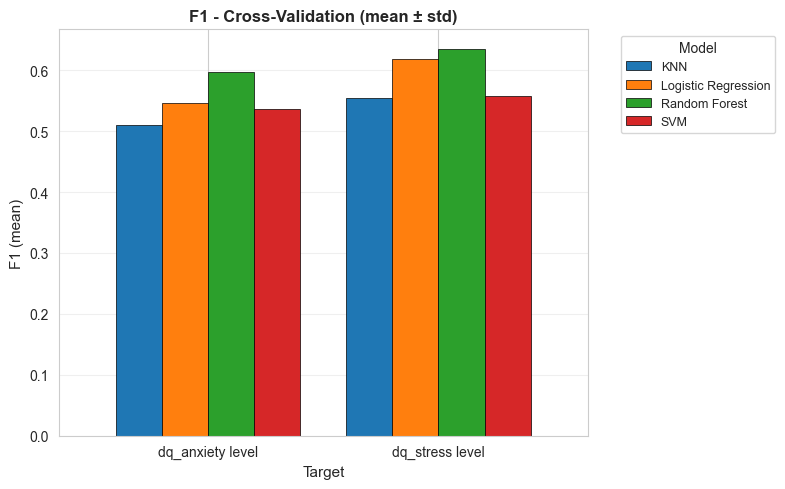

In [25]:
# Essential bar comparison charts for Cross-Validation results (separate figures for each metric)
if not cv_df.empty:
    metrics = ['Accuracy', 'Precision', 'Recall', 'F1']
    for metric in metrics:
        fig, ax = plt.subplots(figsize=(8, 5))
        # Use mean values for the chart
        pivot_data = cv_df.pivot(index="target", columns="model", values=f"{metric}_mean")
        
        pivot_data.plot(kind='bar', ax=ax, width=0.8, edgecolor='black', linewidth=0.5)
        ax.set_title(f'{metric} - Cross-Validation (mean ± std)', 
                     fontsize=12, fontweight='bold')
        ax.set_ylabel(f'{metric} (mean)', fontsize=11)
        ax.set_xlabel('Target', fontsize=11)
        ax.legend(title='Model', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
        ax.grid(axis='y', alpha=0.3)
        ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
        
        plt.tight_layout()
        plt.show()
else:
    print("No CV results available for charting")


### 22. Cross-Validation Performance Heatmaps


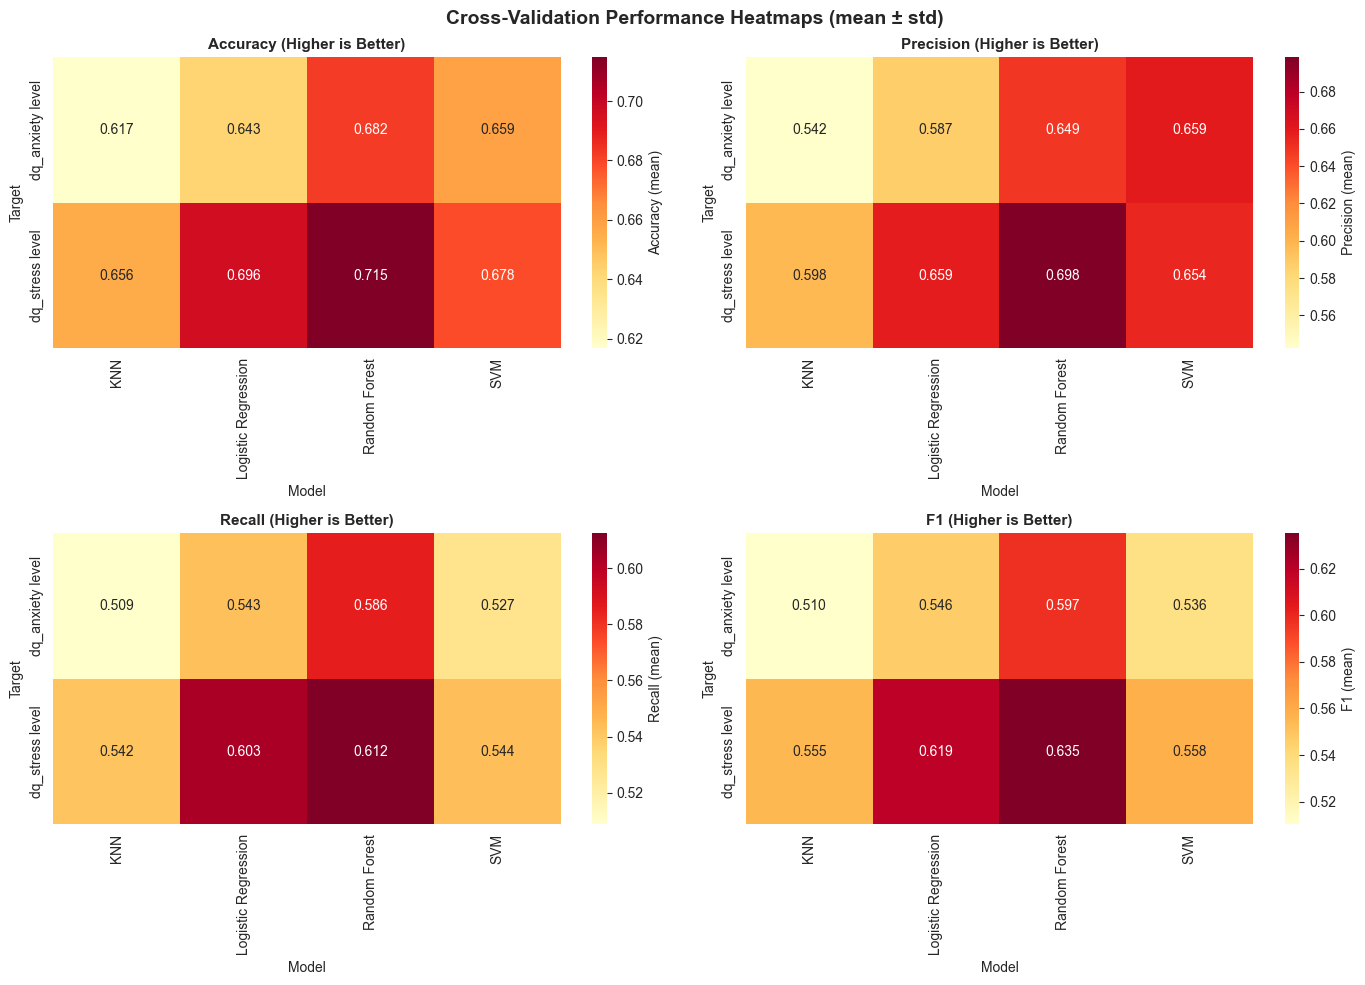

In [26]:
# Create heatmap of Cross-Validation performance metrics
if not cv_df.empty:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle('Cross-Validation Performance Heatmaps (mean ± std)', fontsize=14, fontweight='bold')
    
    metrics = ['Accuracy', 'Precision', 'Recall', 'F1']
    for idx, metric in enumerate(metrics):
        ax = axes[idx // 2, idx % 2]
        # Use mean values for the heatmap
        pivot_data = cv_df.pivot(index="target", columns="model", values=f"{metric}_mean")
        
        sns.heatmap(pivot_data, annot=True, fmt='.3f', cmap='YlOrRd', 
                    ax=ax, cbar_kws={'label': f'{metric} (mean)'})
        ax.set_title(f'{metric} (Higher is Better)', fontsize=11, fontweight='bold')
        ax.set_xlabel('Model', fontsize=10)
        ax.set_ylabel('Target', fontsize=10)
    
    plt.tight_layout()
    plt.show()
else:
    print("No CV results available for heatmap")
